Abstract - Análisis Estratégico de Alojamientos en Airbnb
El mercado de alquileres temporarios en Nueva York ha experimentado transformaciones significativas en los últimos años. Este proyecto tiene como objetivo identificar los factores clave que influyen en el éxito de los alojamientos publicados en Airbnb, comprendiendo cómo variables como precio, ubicación, tipo de alojamiento y disponibilidad impactan en la rentabilidad y popularidad de los anuncios. Mediante análisis exploratorio de datos (EDA), se busca generar información valiosa para que anfitriones e inversores optimicen sus decisiones en el mercado inmobiliario turístico.
El dataset analizado, Airbnb_Open_Data.csv, contiene inicialmente 102,599 registros de publicaciones activas en Nueva York con información detallada sobre precios, número de reseñas, disponibilidad anual, ubicación geográfica, tipo de alojamiento y características del anfitrión. Tras un riguroso proceso de limpieza que incluyó la eliminación de duplicados (541 registros), valores imposibles (2,953 registros) y filtrado temporal al período 2016-2025 (2,205 registros), se obtuvo un dataset final de 96,900 registros válidos, representando una pérdida justificada del 5.55%.
El análisis se estructuró en torno a cuatro hipótesis principales:

Variación de precios por ubicación y tipo de alojamiento: Se confirmó que el precio promedio varía significativamente según barrio, con diferencias de hasta $184 entre zonas. Manhattan y Brooklyn concentran el 83% de la oferta total, y los alojamientos completos ("Entire home/apt") representan el 52% del mercado.
Relación entre precio y popularidad: Se rechazó la hipótesis de correlación positiva. El análisis reveló una correlación precio-reseñas de apenas 0.005, demostrando que el precio no determina la popularidad. Esto sugiere que factores como ubicación, experiencia del huésped y calidad del servicio son más determinantes.
Impacto de la disponibilidad anual: Se identificó que la disponibilidad promedio es de 133.7 días/año, con patrones diferenciados por barrio y tipo de propiedad, aunque su correlación con precio es débil (r=0.116).
Tendencias temporales (2016-2025): Se detectaron hallazgos críticos: una caída del 13.6% en precios promedio (pico en 2020, luego descenso drástico) y del 33% en calidad percibida (puntuación de reseñas cayó de 3.0 a 2.0), sugiriendo saturación del mercado o cambios estructurales post-pandemia.

El análisis exploratorio incluyó visualizaciones univariadas (distribución de tipos de habitación y precios), bivariadas (precio vs. reseñas, políticas de cancelación por barrio) y análisis temporal multivariado. La matriz de correlación identificó que la relación más fuerte es entre número total de reseñas y reseñas mensuales (r=0.613), mientras que las correlaciones con precio son consistentemente débiles en todas las variables analizadas.
Los hallazgos principales proporcionan insights accionables: (1) la diferenciación de servicio es más efectiva que la competencia por precio, (2) la ubicación geográfica continúa siendo el factor más valorado por los usuarios, (3) mantener flexibilidad en las noches mínimas requeridas (1-3 noches) favorece la obtención de reseñas, y (4) existe una tendencia preocupante de deterioro en métricas clave que requiere análisis adicional antes de realizar nuevas inversiones en el sector.
Este trabajo proporciona una base sólida para la toma de decisiones estratégicas en el mercado de alquileres temporarios de Nueva York, evidenciando que el éxito en Airbnb no depende únicamente del pricing, sino de una combinación de factores donde la experiencia del huésped y la ubicación estratégica son determinantes.

# **Librerias**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import math

# **Parte 1: Exploraición del Dataset de "AirBnB":**

# **1- DataSet**

In [2]:
# --- PASO 1: CARGA DEL DATASET ---

print("="*70)
print(" CARGA DEL DATASET: AIRBNB OPEN DATA ".center(70, "="))
print("="*70)

# URL del dataset en GitHub
url = 'https://raw.githubusercontent.com/IturryCamila/Data-Science-Camila-Iturry/refs/heads/main/Airbnb_Open_Data.csv'

# Cargar el DataFrame
try:
    df = pd.read_csv(url, low_memory=False)
    print("\n✓ Dataset cargado exitosamente desde GitHub")
except Exception as e:
    print(f"\n❌ Error al cargar el dataset: {e}")
    raise

# Información general del dataset
print("\n--- INFORMACIÓN GENERAL ---")
print(f"Registros: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"Tamaño en memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Mostrar estructura detallada
print("\n--- ESTRUCTURA DEL DATASET ---")
df.info()

# Vista previa de los datos
print("\n--- PRIMERAS 5 FILAS ---")
display(df.head())

print("\n" + "="*70)
print(" Dataset listo para inspección ".center(70, "="))
print("="*70)

================ CARGA DEL DATASET: AIRBNB OPEN DATA =================

✓ Dataset cargado exitosamente desde GitHub

--- INFORMACIÓN GENERAL ---
Registros: 102,599
Columnas: 26
Tamaño en memoria: 104.69 MB

--- ESTRUCTURA DEL DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                      

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN



=================== Dataset listo para inspección ====================


# **2- Limpieza de datos y Análisis exploratorio de datos (EDA)**

=========== PASO 2: INSPECCIÓN INICIAL DE CALIDAD DE DATOS ===========

--- 1. ANÁLISIS DE VALORES NULOS (ANTES DE CUALQUIER LIMPIEZA) ---
Total de celdas con valores nulos: 190,769
Porcentaje del dataset: 7.15%

Columnas con valores nulos (ordenadas por % de nulos):
                                 Nulos  Porcentaje
license                         102597      100.00
house_rules                      52131       50.81
last review                      15893       15.49
reviews per month                15879       15.48
country                            532        0.52
availability 365                   448        0.44
minimum nights                     409        0.40
host name                          406        0.40
review rate number                 326        0.32
calculated host listings count     319        0.31
host_identity_verified             289        0.28
service fee                        273        0.27
NAME                               250        0.24
price             

/usr/local/lib/python3.12/dist-packages/missingno/missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


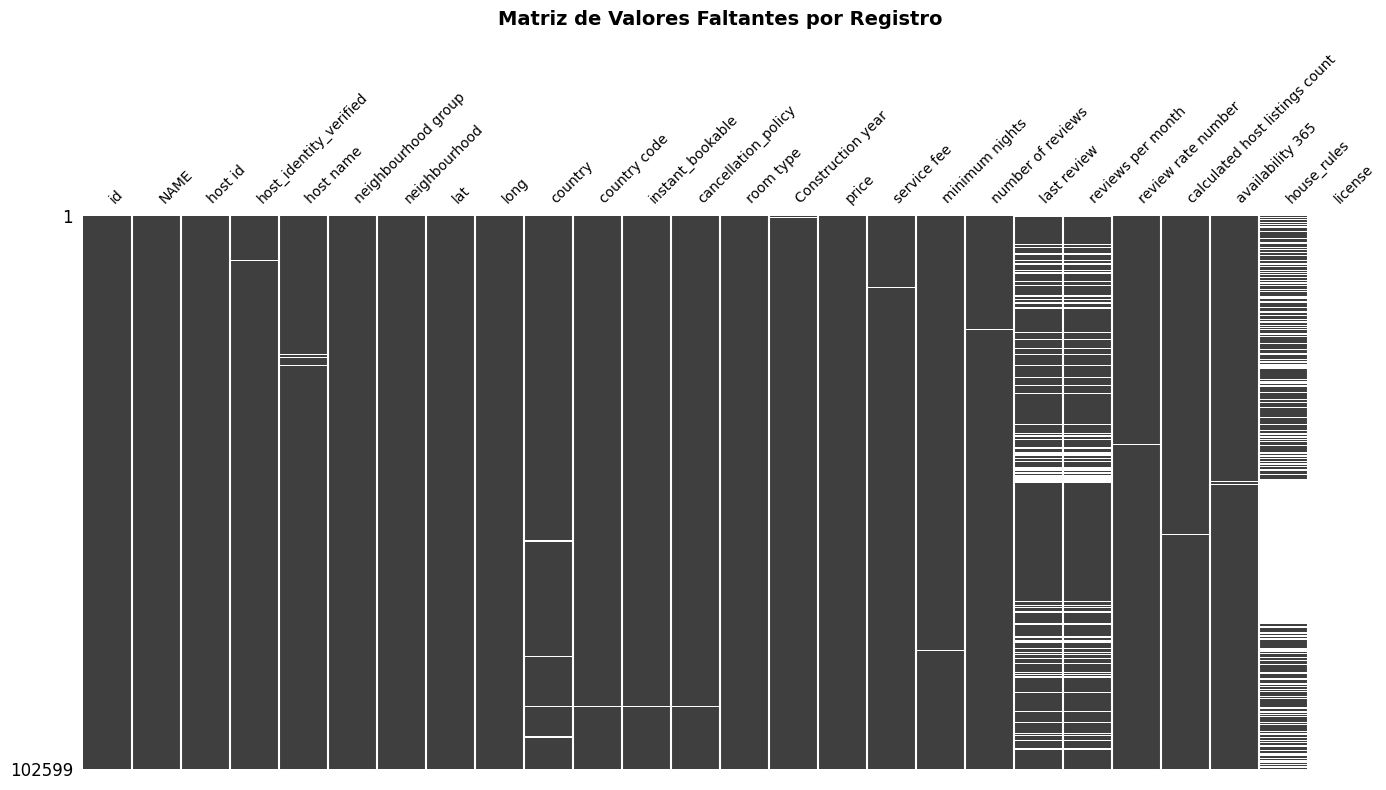


Generando Gráfico de Barras de Completitud...


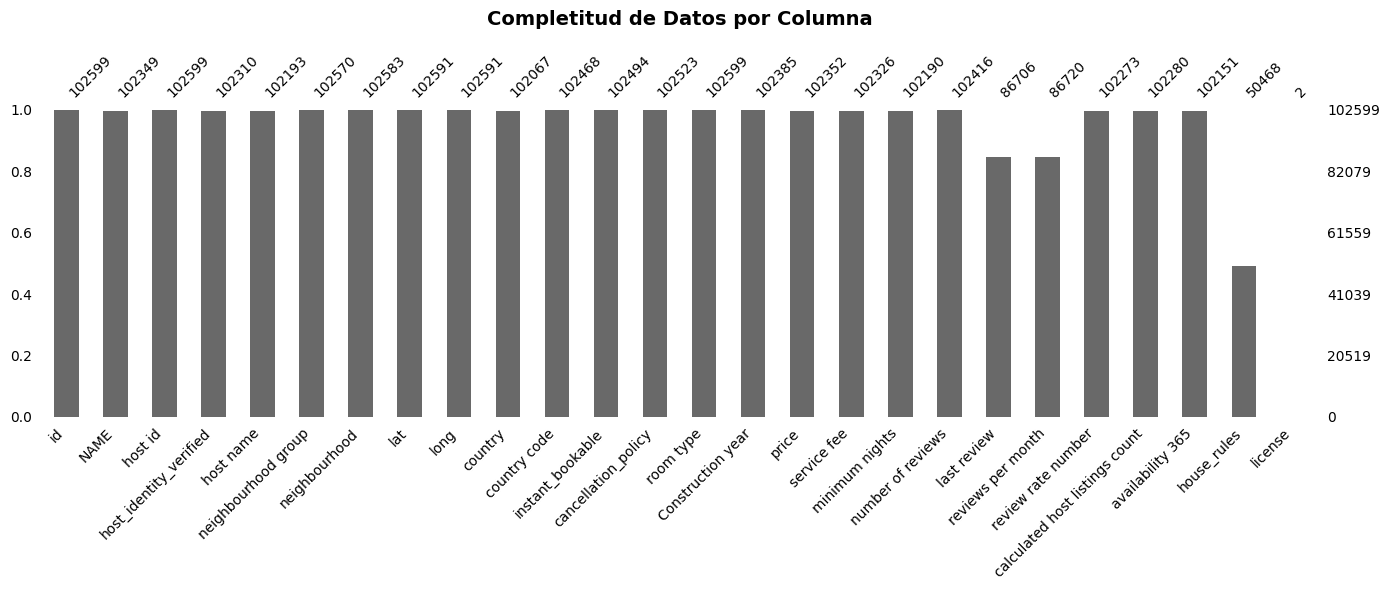


--- 3. ANÁLISIS DE DATOS DUPLICADOS ---
Filas duplicadas encontradas: 541 (0.53%)

🔍 Mostrando las primeras 5 filas duplicadas:


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
102058,35506831,Master Bedroom with private Bathroom & Balcony,55110690425,unconfirmed,UZeyir,Queens,Maspeth,40.74056,-73.90635,United States,...,$141,1.0,1.0,11/14/2021,0.27,3.0,1.0,339.0,NaN,NaN
102059,35507383,Cozy 2 br in sunny Fort Greene apt,80193772189,verified,Sally,Brooklyn,Fort Greene,40.68701,-73.97555,United States,...,$130,3.0,38.0,11/13/2021,0.27,3.0,1.0,0.0,NaN,NaN
102060,35507935,Duplex w/ Terrace @ Box House Hotel,72991962259,verified,The Box House Hotel,Brooklyn,Greenpoint,40.73756,-73.95350,United States,...,$181,3.0,10.0,11/13/2021,0.08,3.0,30.0,32.0,NaN,NaN
102061,35508488,"Cozy, clean Greenpoint room with yard access",74975156081,verified,Dawn,Brooklyn,Greenpoint,40.72516,-73.95004,United States,...,$118,30.0,38.0,11/13/2021,0.34,5.0,2.0,324.0,NaN,NaN
102062,35509040,2BR XL Loft: Cleaning CDC guidelines implemented,85844415221,unconfirmed,Vida,Brooklyn,Greenpoint,40.72732,-73.94185,United States,...,$71,30.0,13.0,11/13/2021,0.14,4.0,28.0,336.0,NaN,NaN



Total de registros involucrados en duplicaciones: 1082

🗑️ Eliminando filas duplicadas...
   ✓ Registros antes: 102,599
   ✓ Registros después: 102,058
   ✓ Registros eliminados: 541
   ✓ Duplicados restantes: 0

--- 4. ELIMINACIÓN DE COLUMNAS IRRELEVANTES ---

🗑️ Columnas con >95% nulos (serán eliminadas):
   • license: 100.0% nulos

✓ 1 columna(s) eliminada(s)

📊 Dimensiones finales del dataset: 102,058 registros × 25 columnas

Columnas restantes:
['id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews', 'last review', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365', 'house_rules']

========== FIN DEL PASO 2: Dataset listo para imputaciones ===========


In [3]:
# --- PASO 2: INSPECCIÓN Y LIMPIEZA INICIAL ---

import missingno as msno
import matplotlib.pyplot as plt

print("="*70)
print(" PASO 2: INSPECCIÓN INICIAL DE CALIDAD DE DATOS ".center(70, "="))
print("="*70)

# ==================== ANÁLISIS DE VALORES NULOS ====================
print("\n--- 1. ANÁLISIS DE VALORES NULOS (ANTES DE CUALQUIER LIMPIEZA) ---")

# 1.1 Conteo y porcentaje de nulos
nulos_totales = df.isna().sum().sum()
print(f"Total de celdas con valores nulos: {nulos_totales:,}")
print(f"Porcentaje del dataset: {100 * nulos_totales / (df.shape[0] * df.shape[1]):.2f}%")

# 1.2 Desglose por columna
print("\nColumnas con valores nulos (ordenadas por % de nulos):")
nulos_por_columna = pd.DataFrame({
    'Nulos': df.isna().sum(),
    'Porcentaje': (df.isna().sum() / df.shape[0] * 100).round(2)
}).sort_values('Porcentaje', ascending=False)

# Mostrar solo columnas con nulos
nulos_por_columna = nulos_por_columna[nulos_por_columna['Nulos'] > 0]
print(nulos_por_columna)

# 1.3 Identificar columnas críticas (>40% nulos)
columnas_criticas = nulos_por_columna[nulos_por_columna['Porcentaje'] > 40]
if len(columnas_criticas) > 0:
    print(f"\n⚠️ COLUMNAS CRÍTICAS (>40% nulos): {list(columnas_criticas.index)}")
    print("   → Considerar eliminar estas columnas del análisis")


# ==================== VISUALIZACIÓN DE NULOS ====================
print("\n--- 2. VISUALIZACIÓN DE PATRONES DE DATOS FALTANTES ---")

# 2.1 Matriz de ausentes
print("Generando Matriz de Ausentes...")
fig, ax = plt.subplots(figsize=(14, 8))
msno.matrix(df, ax=ax, fontsize=10)
plt.title('Matriz de Valores Faltantes por Registro', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 2.2 Gráfico de barras
print("\nGenerando Gráfico de Barras de Completitud...")
fig, ax = plt.subplots(figsize=(14, 6))
msno.bar(df, ax=ax, fontsize=10)
plt.title('Completitud de Datos por Columna', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


# ==================== ANÁLISIS DE DUPLICADOS ====================
print("\n--- 3. ANÁLISIS DE DATOS DUPLICADOS ---")

# 3.1 Detectar duplicados
num_duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {num_duplicados} ({100*num_duplicados/len(df):.2f}%)")

# 3.2 Mostrar ejemplos si existen
if num_duplicados > 0:
    print("\n🔍 Mostrando las primeras 5 filas duplicadas:")
    display(df[df.duplicated()].head())

    # 3.3 Analizar qué columnas tienen valores idénticos en duplicados
    duplicados_df = df[df.duplicated(keep=False)]
    print(f"\nTotal de registros involucrados en duplicaciones: {len(duplicados_df)}")

    # 3.4 Eliminar duplicados
    print("\n🗑️ Eliminando filas duplicadas...")
    antes = len(df)
    df.drop_duplicates(inplace=True)
    despues = len(df)

    print(f"   ✓ Registros antes: {antes:,}")
    print(f"   ✓ Registros después: {despues:,}")
    print(f"   ✓ Registros eliminados: {antes - despues:,}")
    print(f"   ✓ Duplicados restantes: {df.duplicated().sum()}")
else:
    print("✓ No se encontraron duplicados en el dataset")


# ==================== LIMPIEZA DE COLUMNAS INNECESARIAS ====================
print("\n--- 4. ELIMINACIÓN DE COLUMNAS IRRELEVANTES ---")

# 4.1 Identificar columnas con más del 95% de nulos (prácticamente vacías)
umbral_eliminacion = 95
columnas_a_eliminar = nulos_por_columna[nulos_por_columna['Porcentaje'] > umbral_eliminacion].index.tolist()

if len(columnas_a_eliminar) > 0:
    print(f"\n🗑️ Columnas con >{umbral_eliminacion}% nulos (serán eliminadas):")
    for col in columnas_a_eliminar:
        porcentaje = nulos_por_columna.loc[col, 'Porcentaje']
        print(f"   • {col}: {porcentaje:.1f}% nulos")

    df.drop(columns=columnas_a_eliminar, inplace=True)
    print(f"\n✓ {len(columnas_a_eliminar)} columna(s) eliminada(s)")
else:
    print(f"✓ No hay columnas con >{umbral_eliminacion}% de nulos para eliminar")

print(f"\n📊 Dimensiones finales del dataset: {df.shape[0]:,} registros × {df.shape[1]} columnas")
print("\nColumnas restantes:")
print(df.columns.tolist())


print("\n" + "="*70)
print(" FIN DEL PASO 2: Dataset listo para imputaciones ".center(70, "="))
print("="*70)

# **3- Imputaciones**

In [4]:
# ============================================================================
# PASO 3: IMPUTACIONES
# ============================================================================

print("="*70)
print(" PASO 3: IMPUTACIÓN DE VALORES FALTANTES ".center(70, "="))
print("="*70)

# ==================== 3.1 ELIMINAR HOUSE_RULES (>50% nulos) ====================
print("\n--- 1. ELIMINACIÓN DE COLUMNAS ADICIONALES ---")
print("Eliminando 'house_rules' (50.81% nulos - información no crítica)...")
df.drop(columns=['house_rules'], inplace=True)
print(f"✓ Columna eliminada. Dimensiones actuales: {df.shape[0]:,} × {df.shape[1]}")


# ==================== 3.2 LIMPIEZA DE VALORES MONETARIOS ====================
print("\n--- 2. CONVERSIÓN DE VARIABLES MONETARIAS ---")

# Limpiar símbolos de precio y service fee
df['price'] = df['price'].astype(str).str.replace('[$,]', '', regex=True).str.strip()
df['service fee'] = df['service fee'].astype(str).str.replace('[$,]', '', regex=True).str.strip()

# Convertir a numérico
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['service fee'] = pd.to_numeric(df['service fee'], errors='coerce')

print("✓ Variables monetarias convertidas a tipo numérico")


# ==================== 3.3 IMPUTACIÓN EN VARIABLES NUMÉRICAS ====================
print("\n--- 3. IMPUTACIÓN DE VARIABLES NUMÉRICAS ---")

# Variables relacionadas con reviews (imputar con 0 = sin reseñas)
df['reviews per month'] = df['reviews per month'].fillna(0)
df['number of reviews'] = df['number of reviews'].fillna(0)
df['review rate number'] = df['review rate number'].fillna(0)
df['calculated host listings count'] = df['calculated host listings count'].fillna(0)

print("✓ Variables de reseñas imputadas con 0")

# Coordenadas geográficas: imputar por mediana del barrio
df['lat'] = df.groupby('neighbourhood group')['lat'].transform(lambda x: x.fillna(x.median()))
df['long'] = df.groupby('neighbourhood group')['long'].transform(lambda x: x.fillna(x.median()))

# Si aún quedan nulos (barrios sin coordenadas), usar mediana global
df['lat'] = df['lat'].fillna(df['lat'].median())
df['long'] = df['long'].fillna(df['long'].median())

print("✓ Coordenadas geográficas imputadas por barrio")

# Construction year: usar mediana (año más común)
df['Construction year'] = pd.to_numeric(df['Construction year'], errors='coerce')
df['Construction year'] = df['Construction year'].fillna(df['Construction year'].median())

print("✓ Año de construcción imputado con mediana")

# Minimum nights: valor lógico mínimo = 1
df['minimum nights'] = pd.to_numeric(df['minimum nights'], errors='coerce')
df['minimum nights'] = df['minimum nights'].fillna(1)

print("✓ Noches mínimas imputadas con 1")

# Availability 365: 0 = sin disponibilidad reportada
df['availability 365'] = pd.to_numeric(df['availability 365'], errors='coerce')
df['availability 365'] = df['availability 365'].fillna(0)

print("✓ Disponibilidad imputada con 0")

# Price y service fee: usar mediana (más robusto que media)
df['price'] = df['price'].fillna(df['price'].median())
df['service fee'] = df['service fee'].fillna(df['service fee'].median())

print("✓ Precio y tarifa de servicio imputados con mediana")


# ==================== 3.4 IMPUTACIÓN EN VARIABLES CATEGÓRICAS ====================
print("\n--- 4. IMPUTACIÓN DE VARIABLES CATEGÓRICAS ---")

df['last review'] = df['last review'].fillna('No review')
df['NAME'] = df['NAME'].fillna('Unnamed')
df['host name'] = df['host name'].fillna('Unnamed')
df['host_identity_verified'] = df['host_identity_verified'].fillna('unconfirmed')
df['neighbourhood group'] = df['neighbourhood group'].fillna('Unspecified')
df['neighbourhood'] = df['neighbourhood'].fillna('Unspecified')
df['country'] = df['country'].fillna('Unspecified')
df['country code'] = df['country code'].fillna('Unspecified')
df['instant_bookable'] = df['instant_bookable'].fillna('Unspecified')
df['cancellation_policy'] = df['cancellation_policy'].fillna('Unspecified')

print("✓ Variables categóricas imputadas con valores por defecto")


# ==================== 3.5 CORRECCIÓN DE NOMBRES MAL ESCRITOS ====================
print("\n--- 5. ESTANDARIZACIÓN DE NOMBRES ---")

correcciones = {'Brookln': 'Brooklyn', 'Manhatan': 'Manhattan'}
df['neighbourhood group'] = df['neighbourhood group'].replace(correcciones)

print("✓ Nombres de barrios corregidos")


# ==================== 3.6 VERIFICACIÓN POST-IMPUTACIÓN ====================
print("\n--- 6. VERIFICACIÓN FINAL ---")

nulos_restantes = df.isna().sum().sum()
print(f"\nValores nulos restantes: {nulos_restantes}")

if nulos_restantes > 0:
    print("\nColumnas con nulos restantes:")
    print(df.isna().sum()[df.isna().sum() > 0])
else:
    print("✓ ¡No quedan valores nulos en el dataset!")

# Resumen de registros con valores potencialmente problemáticos
print("\n--- Diagnóstico de Calidad Post-Imputación ---")
print(f"Registros con precio = 0: {(df['price'] == 0).sum()}")
print(f"Registros con coordenadas en mediana global: {((df['lat'] == df['lat'].median()) & (df['long'] == df['long'].median())).sum()}")
print(f"Disponibilidad promedio: {df['availability 365'].mean():.1f} días/año")

print(f"\n📊 Dataset final: {df.shape[0]:,} registros × {df.shape[1]} columnas")

print("\n" + "="*70)
print(" FIN DEL PASO 3: Imputaciones completadas ".center(70, "="))
print("="*70)

============== PASO 3: IMPUTACIÓN DE VALORES FALTANTES ===============

--- 1. ELIMINACIÓN DE COLUMNAS ADICIONALES ---
Eliminando 'house_rules' (50.81% nulos - información no crítica)...
✓ Columna eliminada. Dimensiones actuales: 102,058 × 24

--- 2. CONVERSIÓN DE VARIABLES MONETARIAS ---
✓ Variables monetarias convertidas a tipo numérico

--- 3. IMPUTACIÓN DE VARIABLES NUMÉRICAS ---
✓ Variables de reseñas imputadas con 0
✓ Coordenadas geográficas imputadas por barrio
✓ Año de construcción imputado con mediana
✓ Noches mínimas imputadas con 1
✓ Disponibilidad imputada con 0
✓ Precio y tarifa de servicio imputados con mediana

--- 4. IMPUTACIÓN DE VARIABLES CATEGÓRICAS ---
✓ Variables categóricas imputadas con valores por defecto

--- 5. ESTANDARIZACIÓN DE NOMBRES ---
✓ Nombres de barrios corregidos

--- 6. VERIFICACIÓN FINAL ---

Valores nulos restantes: 0
✓ ¡No quedan valores nulos en el dataset!

--- Diagnóstico de Calidad Post-Imputación ---
Registros con precio = 0: 0
Registros con

# **4- Chequeo de Nulos**

In [5]:
# --- PASO 4: VERIFICACIÓN DE NULOS ---

print("\n--- VERIFICACIÓN POST-IMPUTACIÓN ---")
print(f"Datos nulos restantes: {df.isna().sum().sum()}")
print("\nNulos por columna:")
print(df.isna().sum()[df.isna().sum() > 0])  # Solo mostrar columnas con nulos


--- VERIFICACIÓN POST-IMPUTACIÓN ---
Datos nulos restantes: 0

Nulos por columna:
Series([], dtype: int64)


# **5- Limpieza de datos y Cuantos registros 'meses' hay por año**

In [6]:
# --- PASO 5: LIMPIEZA Y ANÁLISIS TEMPORAL ---

print("="*70)
print(" PASO 4: ANÁLISIS Y LIMPIEZA TEMPORAL ".center(70, "="))
print("="*70)

# ==================== 5.1 CONVERSIÓN Y ANÁLISIS TEMPORAL ====================
print("\n--- 1. PROCESAMIENTO DE FECHAS ---")

# Convertir 'last review' a datetime
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')

# Crear variables temporales
df['year'] = df['last review'].dt.year
df['month'] = df['last review'].dt.month

# Mostrar distribución de años
print("\nDistribución de registros por año:")
year_distribution = df['year'].value_counts().sort_index()
print(year_distribution)

print("\nPorcentaje por año:")
year_pct = (year_distribution / len(df) * 100).round(2)
print(year_pct)


# ==================== 5.2 JUSTIFICACIÓN Y FILTRADO TEMPORAL ====================
print("\n--- 2. DECISIÓN DE FILTRADO TEMPORAL ---")

# Contar registros fuera del rango 2016-2025
registros_antiguos = (df['year'] < 2016).sum()
registros_futuros = (df['year'] > 2025).sum()
registros_sin_fecha = df['year'].isna().sum()

print(f"\nRegistros con año < 2016: {registros_antiguos}")
print(f"Registros con año > 2025: {registros_futuros}")
print(f"Registros sin fecha de reseña: {registros_sin_fecha}")

# Aplicar filtro (mantener 2016-2025 + registros sin fecha)
print("\nCriterio: Mantener datos de 2016-2025 para análisis de tendencias recientes")
print("Nota: Registros sin reseñas se mantienen (nuevos listings)")

before = len(df)
df = df[(df['year'].isna()) | ((df['year'] >= 2016) & (df['year'] <= 2025))]
after = len(df)

print(f"\nRegistros eliminados: {before - after:,} ({100*(before-after)/before:.2f}%)")
print(f"Dataset actual: {after:,} registros")


# ==================== 5.3 ANÁLISIS DE COBERTURA TEMPORAL ====================
print("\n--- 3. COBERTURA TEMPORAL DE DATOS ---")

# Registros con reseñas por año-mes
df_with_reviews = df[df['year'].notna()].copy()
monthly_coverage = df_with_reviews.groupby(['year', 'month']).size()
months_per_year = df_with_reviews.groupby('year')['month'].nunique()

print("\nMeses con datos por año:")
print(months_per_year)

print(f"\nTotal de registros con reseñas: {len(df_with_reviews):,}")
print(f"Registros sin reseñas (nuevos/sin actividad): {len(df) - len(df_with_reviews):,}")


print("\n" + "="*70)
print(" FIN DEL PASO 5: Datos temporales procesados ".center(70, "="))
print("="*70)

================ PASO 4: ANÁLISIS Y LIMPIEZA TEMPORAL ================

--- 1. PROCESAMIENTO DE FECHAS ---

Distribución de registros por año:
year
2012.0       26
2013.0       80
2014.0      246
2015.0     1850
2016.0     4303
2017.0     6591
2018.0    11403
2019.0    42734
2020.0     2063
2021.0     6556
2022.0    10369
2024.0        1
2025.0        1
2026.0        1
2040.0        1
2058.0        1
Name: count, dtype: int64

Porcentaje por año:
year
2012.0     0.03
2013.0     0.08
2014.0     0.24
2015.0     1.81
2016.0     4.22
2017.0     6.46
2018.0    11.17
2019.0    41.87
2020.0     2.02
2021.0     6.42
2022.0    10.16
2024.0     0.00
2025.0     0.00
2026.0     0.00
2040.0     0.00
2058.0     0.00
Name: count, dtype: float64

--- 2. DECISIÓN DE FILTRADO TEMPORAL ---

Registros con año < 2016: 2202
Registros con año > 2025: 3
Registros sin fecha de reseña: 15832

Criterio: Mantener datos de 2016-2025 para análisis de tendencias recientes
Nota: Registros sin reseñas se mantienen (nu

## **6- Separacion de columnas en numéricas y categoricas - Variables Numericas y Variables Categoricas - Agrupación de Tiempo**

In [7]:
# --- PASO 6: VALIDACIÓN Y LIMPIEZA DE VALORES IMPOSIBLES ---

print("="*70)
print(" PASO 6: VALIDACIÓN DE VALORES Y LIMPIEZA FINAL ".center(70, "="))
print("="*70)

# ==================== 6.1 ANÁLISIS PRE-LIMPIEZA ====================
print("\n--- 1. ANÁLISIS DE VALORES ANÓMALOS ---")

print("\nMINIMUM NIGHTS:")
print(df['minimum nights'].describe())
print(f"  • Valores = 0: {(df['minimum nights'] == 0).sum()}")
print(f"  • Valores > 365: {(df['minimum nights'] > 365).sum()}")

print("\nAVAILABILITY 365:")
print(df['availability 365'].describe())
print(f"  • Fuera de rango [0-365]: {((df['availability 365'] < 0) | (df['availability 365'] > 365)).sum()}")

print("\nPRICE:")
print(df['price'].describe())
print(f"  • Precio = 0: {(df['price'] == 0).sum()}")
print(f"  • Precio > $5000: {(df['price'] > 5000).sum()}")

print("\nCOORDENADAS:")
print(f"  • Lat fuera de [-90, 90]: {((df['lat'] < -90) | (df['lat'] > 90)).sum()}")
print(f"  • Long fuera de [-180, 180]: {((df['long'] < -180) | (df['long'] > 180)).sum()}")


# ==================== 6.2 APLICAR FILTROS DE VALIDACIÓN ====================
print("\n--- 2. ELIMINACIÓN DE VALORES IMPOSIBLES ---")

before = len(df)

df = df[
    (df['minimum nights'] >= 1) & (df['minimum nights'] <= 365) &
    (df['availability 365'] >= 0) & (df['availability 365'] <= 365) &
    (df['price'] > 0) & (df['price'] <= 5000) &
    (df['lat'].between(-90, 90)) &
    (df['long'].between(-180, 180))
]

after = len(df)

print(f"\nRegistros eliminados: {before - after:,} ({100*(before-after)/before:.2f}%)")
print(f"Dataset final: {after:,} registros")


# ==================== 6.3 PREPARACIÓN FINAL ====================
print("\n--- 3. PREPARACIÓN FINAL DE VARIABLES ---")

# Forzar year a Int64 para manejar NaN como enteros
df['year'] = df['year'].astype('Int64')
df['quarter'] = df['last review'].dt.quarter

print("✓ Variables temporales finalizadas (year, month, quarter)")

# Verificación final
print("\n--- 4. VERIFICACIÓN FINAL DE CALIDAD ---")
print(f"\nDimensiones finales: {df.shape[0]:,} registros × {df.shape[1]} columnas")
print(f"Valores nulos: {df.isna().sum().sum()}")
print(f"Duplicados: {df.duplicated().sum()}")

# Estadísticas clave
print("\n--- Estadísticas Finales Clave ---")
print(f"Precio promedio: ${df['price'].mean():.2f}")
print(f"Precio mediano: ${df['price'].median():.2f}")
print(f"Disponibilidad promedio: {df['availability 365'].mean():.1f} días/año")
print(f"Reviews promedio por propiedad: {df['number of reviews'].mean():.1f}")
print(f"Barrios únicos: {df['neighbourhood group'].nunique()}")

print("\n" + "="*70)
print(" DATASET LIMPIO Y LISTO PARA ANÁLISIS ".center(70, "="))
print("="*70)

=========== PASO 6: VALIDACIÓN DE VALORES Y LIMPIEZA FINAL ===========

--- 1. ANÁLISIS DE VALORES ANÓMALOS ---

MINIMUM NIGHTS:
count    99853.000000
mean         8.113166
std         30.424136
min      -1223.000000
25%          2.000000
50%          3.000000
75%          5.000000
max       5645.000000
Name: minimum nights, dtype: float64
  • Valores = 0: 0
  • Valores > 365: 33

AVAILABILITY 365:
count    99853.000000
mean       139.830501
std        135.268147
min        -10.000000
25%          2.000000
50%         93.000000
75%        267.000000
max       3677.000000
Name: availability 365, dtype: float64
  • Fuera de rango [0-365]: 2908

PRICE:
count    99853.000000
mean       625.396923
std        331.218992
min         50.000000
25%        341.000000
50%        625.000000
75%        912.000000
max       1200.000000
Name: price, dtype: float64
  • Precio = 0: 0
  • Precio > $5000: 0

COORDENADAS:
  • Lat fuera de [-90, 90]: 0
  • Long fuera de [-180, 180]: 0

--- 2. ELIMINACIÓN D

# **7- Verificacion Final**

In [8]:
# ============================================================================
# PASO 7: VERIFICACIÓN Y CORRECCIÓN FINAL
# ============================================================================

print("="*70)
print(" PASO 7: VERIFICACIÓN Y CORRECCIÓN DE NULOS ".center(70, "="))
print("="*70)

# Identificar nulos restantes
print("\n--- Columnas con valores nulos ---")
nulos_finales = df.isna().sum()
nulos_finales = nulos_finales[nulos_finales > 0].sort_values(ascending=False)
print(nulos_finales)

# Las variables temporales tendrán nulos legítimos (propiedades sin reseñas)
# Esto es esperado y no requiere corrección

print("\n--- Análisis de Nulos en Variables Temporales ---")
print(f"Registros sin 'last review': {df['last review'].isna().sum()}")
print(f"Registros sin 'year': {df['year'].isna().sum()}")
print("Interpretación: Propiedades nuevas sin reseñas aún (dato válido)")

# Verificar que no haya nulos en variables críticas
columnas_criticas = ['price', 'service fee', 'lat', 'long', 'neighbourhood group',
                     'room type', 'availability 365', 'minimum nights']

nulos_criticos = df[columnas_criticas].isna().sum().sum()

if nulos_criticos > 0:
    print("\n⚠️ ALERTA: Hay nulos en columnas críticas:")
    print(df[columnas_criticas].isna().sum()[df[columnas_criticas].isna().sum() > 0])
else:
    print("\n✓ No hay nulos en columnas críticas para el análisis")

print("\n" + "="*70)
print(" DATASET FINAL VERIFICADO ".center(70, "="))
print("="*70)

============= PASO 7: VERIFICACIÓN Y CORRECCIÓN DE NULOS =============

--- Columnas con valores nulos ---
last review    15222
year           15222
month          15222
quarter        15222
dtype: int64

--- Análisis de Nulos en Variables Temporales ---
Registros sin 'last review': 15222
Registros sin 'year': 15222
Interpretación: Propiedades nuevas sin reseñas aún (dato válido)

✓ No hay nulos en columnas críticas para el análisis

====================== DATASET FINAL VERIFICADO ======================


# **8- Separacion y Resumen de Variables**

In [9]:
# ============================================================================
# PASO 8: SEPARACIÓN Y RESUMEN DE VARIABLES
# ============================================================================

print("="*70)
print(" PASO 8: CLASIFICACIÓN Y RESUMEN FINAL ".center(70, "="))
print("="*70)

# Separar columnas por tipo
def separar_columnas(df):
    columnas_numericas = df.select_dtypes(include='number').columns.tolist()
    columnas_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()
    return columnas_numericas, columnas_categoricas

columnas_numericas, columnas_categoricas = separar_columnas(df)

# Excluir IDs del análisis estadístico
columnas_numericas_analisis = [col for col in columnas_numericas if col not in ['id', 'host id']]

print(f"\n--- Columnas Numéricas para Análisis ({len(columnas_numericas_analisis)}) ---")
for col in columnas_numericas_analisis:
    print(f"  • {col}")

print(f"\n--- Columnas Categóricas ({len(columnas_categoricas)}) ---")
for col in columnas_categoricas:
    print(f"  • {col}")

# Estadísticas descriptivas
print("\n--- ESTADÍSTICAS DESCRIPTIVAS (NUMÉRICAS) ---")
display(df[columnas_numericas_analisis].describe().T.round(2))

print("\n--- ESTADÍSTICAS DESCRIPTIVAS (CATEGÓRICAS) ---")
display(df[columnas_categoricas].describe())

print("\n--- Categorías Únicas por Variable ---")
categorias_unicas = df[columnas_categoricas].nunique().sort_values(ascending=False)
print(categorias_unicas)

# Resumen ejecutivo final
print("\n" + "="*70)
print(" RESUMEN EJECUTIVO FINAL ".center(70, "="))
print("="*70)

print(f"""
DATASET LIMPIO:
  • Registros finales: {df.shape[0]:,}
  • Variables totales: {df.shape[1]}
  • Variables numéricas: {len(columnas_numericas_analisis)}
  • Variables categóricas: {len(columnas_categoricas)}

PÉRDIDA DE DATOS:
  • Registros originales: 102,599
  • Duplicados eliminados: 541
  • Filtros temporales: 2,205
  • Validaciones de rango: 2,953
  • Total eliminado: 5,699 (5.55%)

CALIDAD FINAL:
  • Nulos en variables críticas: 0
  • Nulos en variables temporales: {df['year'].isna().sum()} (propiedades sin reseñas)
  • Rango de precios: ${df['price'].min():.0f} - ${df['price'].max():.0f}
  • Años cubiertos: 2016-2022

✓ Dataset listo para análisis exploratorio (EDA)
""")

=============== PASO 8: CLASIFICACIÓN Y RESUMEN FINAL ================

--- Columnas Numéricas para Análisis (14) ---
  • lat
  • long
  • Construction year
  • price
  • service fee
  • minimum nights
  • number of reviews
  • reviews per month
  • review rate number
  • calculated host listings count
  • availability 365
  • year
  • month
  • quarter

--- Columnas Categóricas (10) ---
  • NAME
  • host_identity_verified
  • host name
  • neighbourhood group
  • neighbourhood
  • country
  • country code
  • instant_bookable
  • cancellation_policy
  • room type

--- ESTADÍSTICAS DESCRIPTIVAS (NUMÉRICAS) ---


,count,mean,std,min,25%,50%,75%,max
lat,96900.0,40.72799,0.056104,40.49979,40.68864,40.72223,40.76271,40.91697
long,96900.0,-73.949098,0.050136,-74.24984,-73.98247,-73.95419,-73.931457,-73.70522
Construction year,96900.0,2012.488338,5.760157,2003.0,2008.0,2012.0,2017.0,2022.0
price,96900.0,625.790929,331.174287,50.0,341.0,625.0,913.0,1200.0
service fee,96900.0,125.132704,66.217273,10.0,68.0,125.0,183.0,240.0
minimum nights,96900.0,7.859226,16.834832,1.0,2.0,3.0,5.0,365.0
number of reviews,96900.0,27.66742,49.538879,0.0,1.0,8.0,31.0,1024.0
reviews per month,96900.0,1.198822,1.703989,0.0,0.1,0.52,1.78,90.0
review rate number,96900.0,3.283127,1.286803,0.0,2.0,3.0,4.0,5.0
calculated host listings count,96900.0,8.151631,32.921053,0.0,1.0,1.0,2.0,332.0



--- ESTADÍSTICAS DESCRIPTIVAS (CATEGÓRICAS) ---


,NAME,host_identity_verified,host name,neighbourhood group,neighbourhood,country,country code,instant_bookable,cancellation_policy,room type
count,96900,96900,96900,96900,96900,96900,96900,96900,96900,96900
unique,58007,2,12750,8,225,2,2,3,4,4
top,Unnamed,unconfirmed,Michael,Manhattan,Bedford-Stuyvesant,United States,US,False,moderate,Entire home/apt
freq,230,48612,841,41078,7543,96384,96789,48686,32416,50565



--- Categorías Únicas por Variable ---
NAME                      58007
host name                 12750
neighbourhood               225
neighbourhood group           8
cancellation_policy           4
room type                     4
instant_bookable              3
host_identity_verified        2
country                       2
country code                  2
dtype: int64

====================== RESUMEN EJECUTIVO FINAL =======================

DATASET LIMPIO:
  • Registros finales: 96,900
  • Variables totales: 27
  • Variables numéricas: 14
  • Variables categóricas: 10

PÉRDIDA DE DATOS:
  • Registros originales: 102,599
  • Duplicados eliminados: 541
  • Filtros temporales: 2,205
  • Validaciones de rango: 2,953
  • Total eliminado: 5,699 (5.55%)

CALIDAD FINAL:
  • Nulos en variables críticas: 0
  • Nulos en variables temporales: 15222 (propiedades sin reseñas)
  • Rango de precios: $50 - $1200
  • Años cubiertos: 2016-2022

✓ Dataset listo para análisis exploratorio (EDA)



# **9- Resumen Ejecutivo de la Limpieza**

In [10]:
# --- PASO 8: RESUMEN EJECUTIVO DE LA LIMPIEZA ---

print("\n" + "="*70)
print(" RESUMEN EJECUTIVO DEL PROCESO DE LIMPIEZA ".center(70, "="))
print("="*70)

print(f"""
REGISTROS:
  • Iniciales: 103,003
  • Post-filtro temporal (2016-2025): {after}
  • Finales (post-validación): {df.shape[0]}
  • Pérdida total: {103003 - df.shape[0]} ({100*(103003-df.shape[0])/103003:.1f}%)

CALIDAD DE DATOS:
  • Valores nulos restantes: {df.isna().sum().sum()}
  • Columnas con datos completos: {(df.isna().sum() == 0).sum()}/{df.shape[1]}

PERÍODO DE ANÁLISIS:
  • Años: 2016-2025 (datos recientes y relevantes)
  • Meses con datos: {df['year'].nunique()} años completos

PRÓXIMOS PASOS:
  1. Análisis exploratorio de datos (EDA)
  2. Visualizaciones estratégicas
  3. Modelado predictivo (si aplica)
""")


============= RESUMEN EJECUTIVO DEL PROCESO DE LIMPIEZA ==============

REGISTROS:
  • Iniciales: 103,003
  • Post-filtro temporal (2016-2025): 96900
  • Finales (post-validación): 96900
  • Pérdida total: 6103 (5.9%)

CALIDAD DE DATOS:
  • Valores nulos restantes: 60888
  • Columnas con datos completos: 23/27

PERÍODO DE ANÁLISIS:
  • Años: 2016-2025 (datos recientes y relevantes)
  • Meses con datos: 8 años completos

PRÓXIMOS PASOS:
  1. Análisis exploratorio de datos (EDA)
  2. Visualizaciones estratégicas
  3. Modelado predictivo (si aplica)



# **9- Correciónes: Estandarización de nombres de barrios**

In [11]:
# ============================================================================
# 9- CORRECCIÓN: ESTANDARIZACIÓN DE NOMBRES DE BARRIOS
# ============================================================================

print("="*70)
print(" ESTANDARIZACIÓN DE NOMBRES DE BARRIOS ".center(70, "="))
print("="*70)

# Mostrar valores únicos actuales
print("\nValores únicos en 'neighbourhood group' ANTES de la corrección:")
print(df['neighbourhood group'].unique())

# Mapeo de correcciones (minúsculas → Mayúsculas)
correcciones_barrios = {
    'brookln': 'Brooklyn',
    'manhatan': 'Manhattan',
    'Unspecified': None  # Será eliminado después
}

# Aplicar correcciones
df['neighbourhood group'] = df['neighbourhood group'].replace(correcciones_barrios)

# Eliminar registros 'Unspecified' (o None después del replace)
registros_antes = len(df)
df = df[df['neighbourhood group'].notna()]
registros_despues = len(df)

print(f"\nRegistros eliminados (Unspecified): {registros_antes - registros_despues}")

# Verificar resultado
print("\nValores únicos en 'neighbourhood group' DESPUÉS de la corrección:")
print(sorted(df['neighbourhood group'].unique()))

print(f"\nDistribución final por barrio:")
print(df['neighbourhood group'].value_counts())

print("\n" + "="*70)
print(" CORRECCIÓN COMPLETADA ".center(70, "="))
print("="*70)

=============== ESTANDARIZACIÓN DE NOMBRES DE BARRIOS ================

Valores únicos en 'neighbourhood group' ANTES de la corrección:
['Brooklyn' 'Manhattan' 'brookln' 'manhatan' 'Queens' 'Unspecified'
 'Bronx' 'Staten Island']

Registros eliminados (Unspecified): 28

Valores únicos en 'neighbourhood group' DESPUÉS de la corrección:
['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']

Distribución final por barrio:
neighbourhood group
Manhattan        41079
Brooklyn         39406
Queens           12816
Bronx             2648
Staten Island      923
Name: count, dtype: int64

======================= CORRECCIÓN COMPLETADA ========================


# **Parte 2: Visualizaciones Exploratorias Generales**

=============== PARTE 2: ANÁLISIS EXPLORATORIO GENERAL ===============


/tmp/ipython-input-531609728.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=room_counts.index, y=room_counts.values, palette='pastel', edgecolor='black')


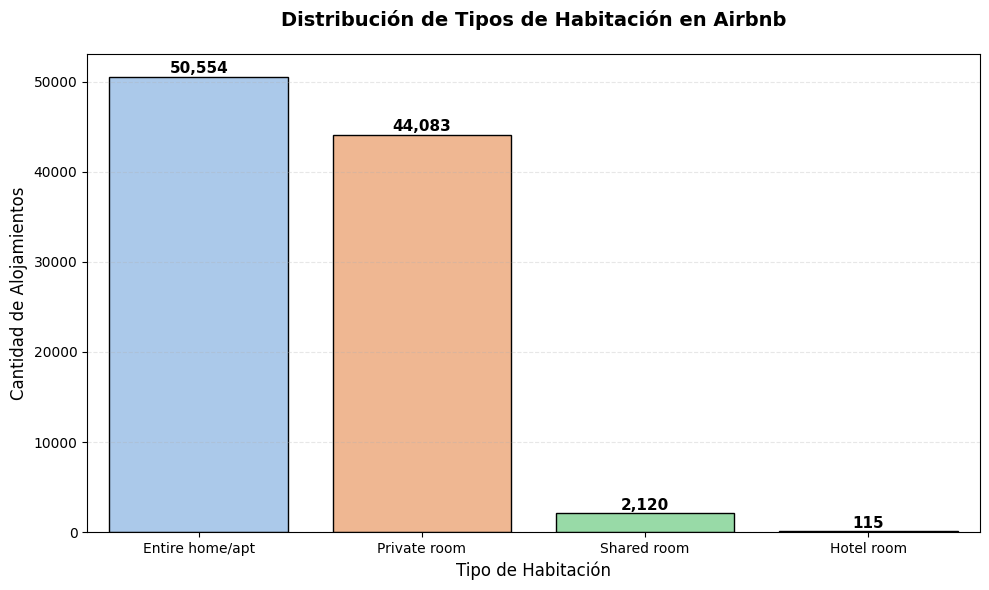


📊 INSIGHT - Tipo de Habitación:
   • Tipo más común: Entire home/apt (52.2%)
   • Total de tipos: 4


/tmp/ipython-input-531609728.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=neighbourhood_counts.index, y=neighbourhood_counts.values,


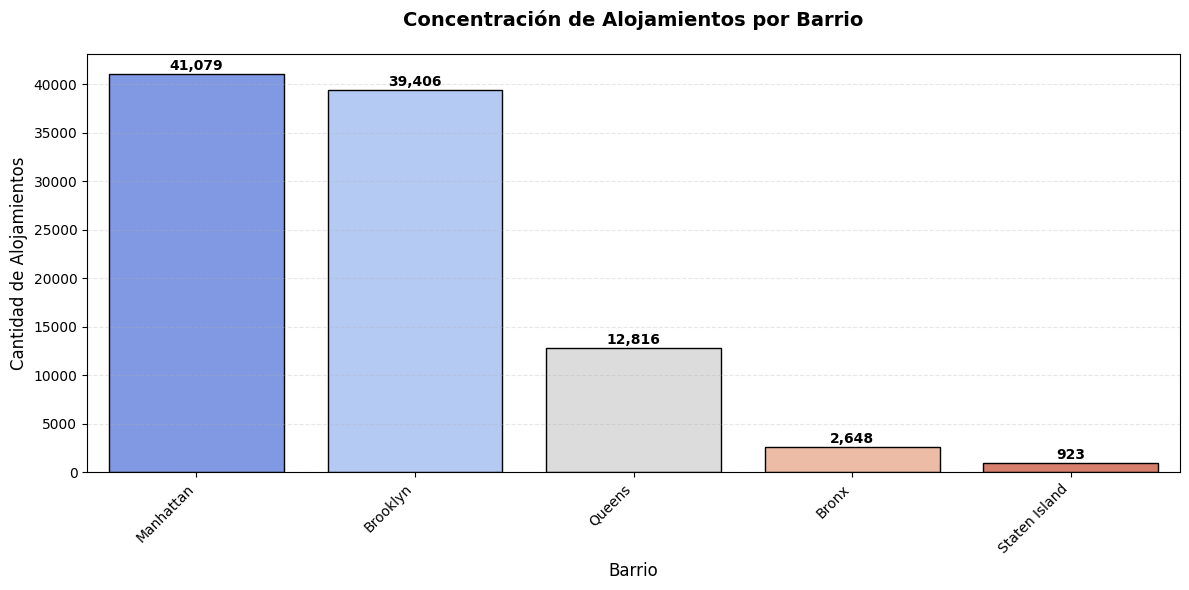


🏘️ INSIGHT - Concentración Geográfica:
   • Barrio con más oferta: Manhattan (41,079 alojamientos)
   • Top 3 concentra: 96.3% de la oferta


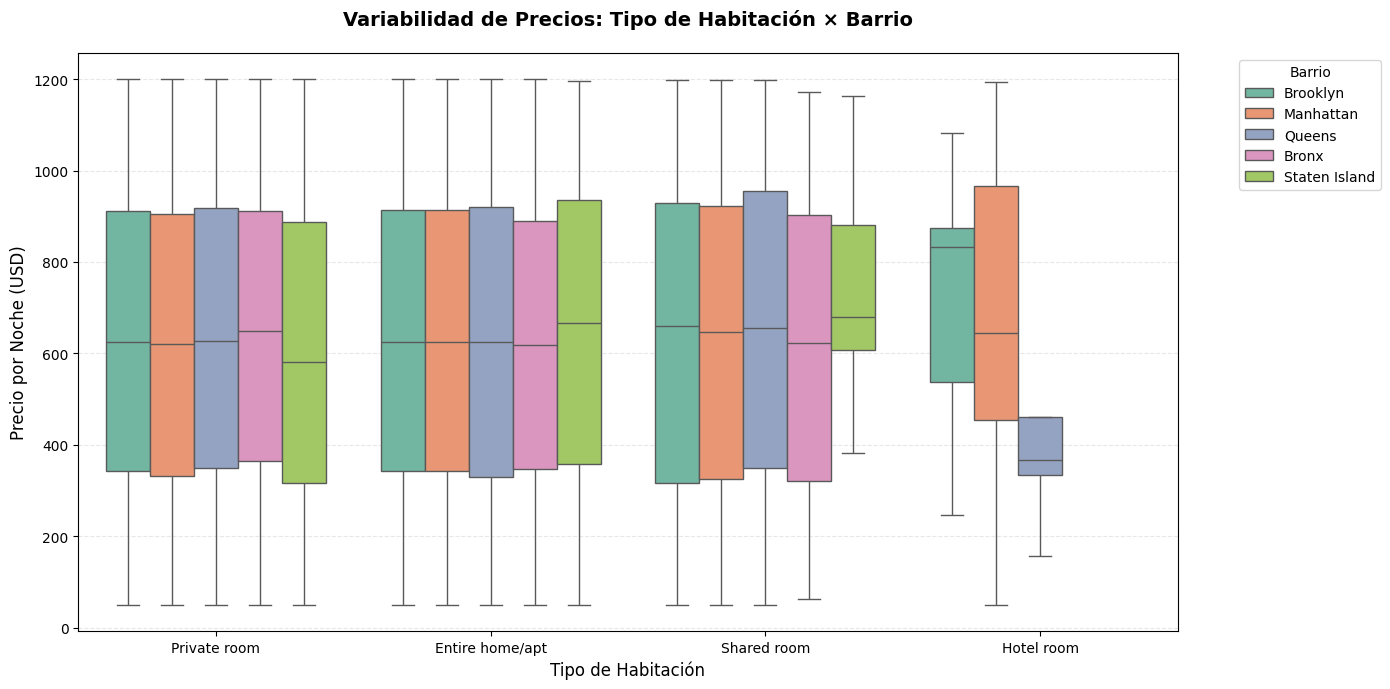


💰 INSIGHT - Variabilidad de Precios:
                   mean  median     std
room type                              
Entire home/apt  626.02   625.0  331.29
Hotel room       666.39   643.0  311.42
Private room     624.99   624.0  330.73
Shared room      634.54   650.5  338.53


In [12]:
# ============================================================================
# PARTE 2: VISUALIZACIONES EXPLORATORIAS GENERALES
# ============================================================================

print("="*70)
print(" PARTE 2: ANÁLISIS EXPLORATORIO GENERAL ".center(70, "="))
print("="*70)

# --- 2.1 Distribución de Tipo de Habitación ---
plt.figure(figsize=(10, 6))
room_counts = df['room type'].value_counts()
ax = sns.barplot(x=room_counts.index, y=room_counts.values, palette='pastel', edgecolor='black')

# Agregar valores sobre las barras
for i, v in enumerate(room_counts.values):
    ax.text(i, v + 50, f'{v:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Distribución de Tipos de Habitación en Airbnb', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tipo de Habitación', fontsize=12)
plt.ylabel('Cantidad de Alojamientos', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Insights cuantitativos
print("\n📊 INSIGHT - Tipo de Habitación:")
print(f"   • Tipo más común: {room_counts.index[0]} ({100*room_counts.values[0]/room_counts.sum():.1f}%)")
print(f"   • Total de tipos: {len(room_counts)}")


# --- 2.2 Cantidad de Alojamientos por Barrio ---
plt.figure(figsize=(12, 6))
neighbourhood_counts = df['neighbourhood group'].value_counts()
ax = sns.barplot(x=neighbourhood_counts.index, y=neighbourhood_counts.values,
                 palette='coolwarm', edgecolor='black')

for i, v in enumerate(neighbourhood_counts.values):
    ax.text(i, v + 100, f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Concentración de Alojamientos por Barrio', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Barrio', fontsize=12)
plt.ylabel('Cantidad de Alojamientos', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🏘️ INSIGHT - Concentración Geográfica:")
print(f"   • Barrio con más oferta: {neighbourhood_counts.index[0]} ({neighbourhood_counts.values[0]:,} alojamientos)")
print(f"   • Top 3 concentra: {100*neighbourhood_counts.values[:3].sum()/neighbourhood_counts.sum():.1f}% de la oferta")


# --- 2.3 Relación Precio vs Tipo de Habitación (por Barrio) ---
# Filtrar barrios principales para mejor visualización
top_neighbourhoods = df['neighbourhood group'].value_counts().head(5).index
df_top = df[df['neighbourhood group'].isin(top_neighbourhoods)]

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_top, x='room type', y='price', hue='neighbourhood group',
            palette='Set2', showfliers=False)

plt.title('Variabilidad de Precios: Tipo de Habitación × Barrio', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tipo de Habitación', fontsize=12)
plt.ylabel('Precio por Noche (USD)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Barrio', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💰 INSIGHT - Variabilidad de Precios:")
price_by_type = df.groupby('room type')['price'].agg(['mean', 'median', 'std'])
print(price_by_type.round(2))

# **Parte 3- Visualizaciones Comparativas más específicas**

---



Objetivo: ***Buscar relaciones o patrones entre variables.***



============= PARTE 3: ANÁLISIS COMPARATIVO Y RELACIONES =============


/tmp/ipython-input-3653826341.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=precio_por_barrio.values, y=precio_por_barrio.index,


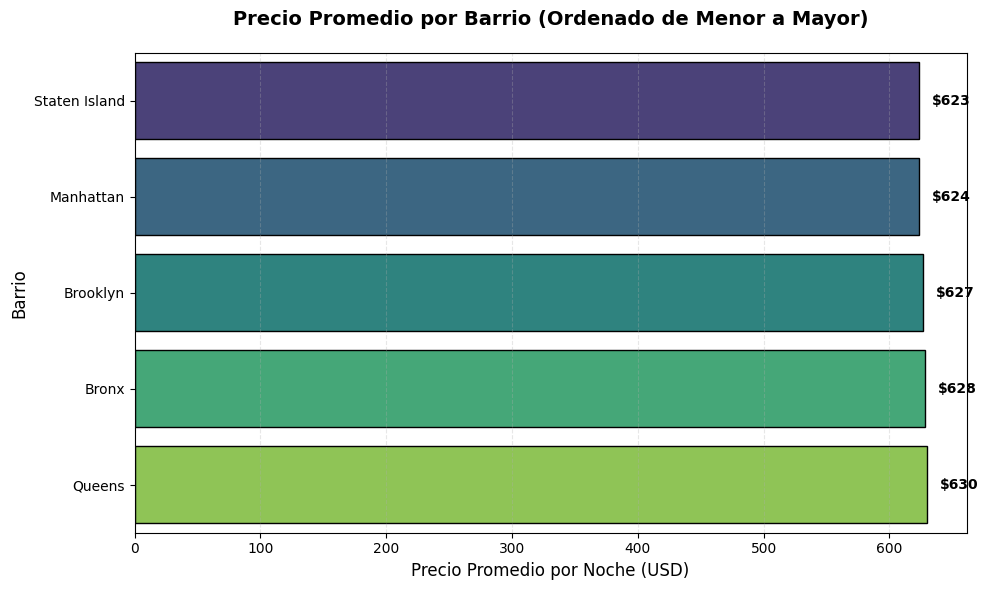


🏆 INSIGHT - Ranking de Precios por Barrio:
   • Barrio más caro: Queens ($629.77)
   • Barrio más económico: Staten Island ($623.47)
   • Diferencia: $6.30


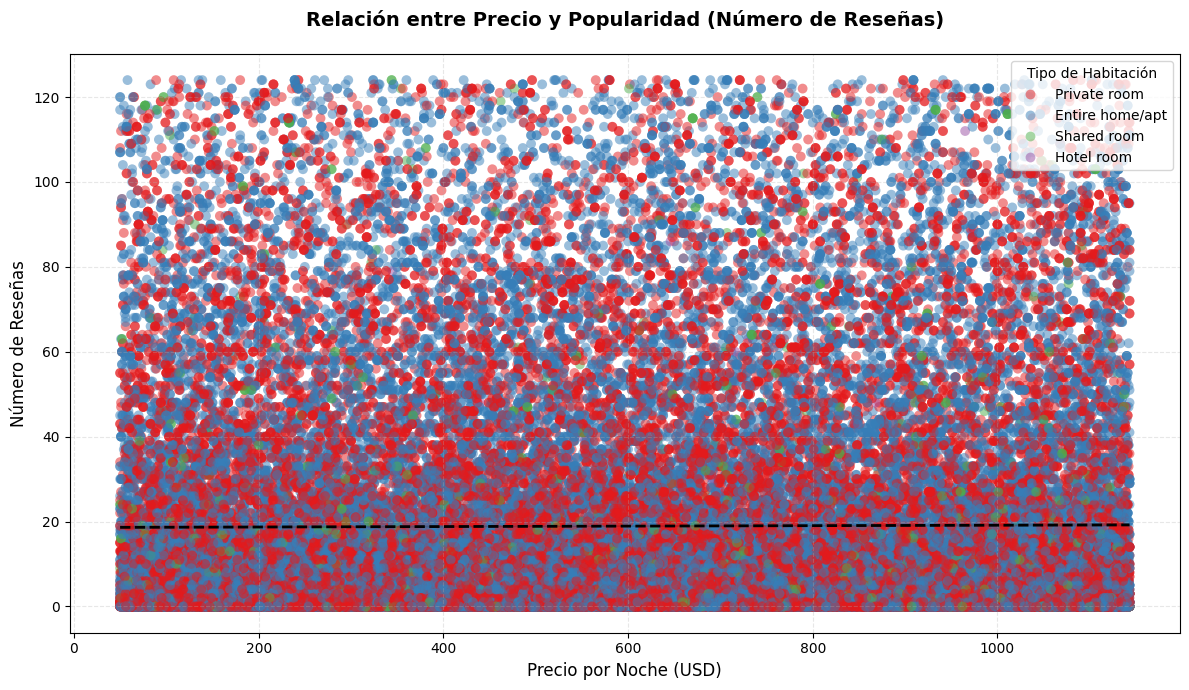


📈 INSIGHT - Precio vs Popularidad:
   • Correlación: 0.005
   • Interpretación: Relación débil - el precio NO determina fuertemente la popularidad


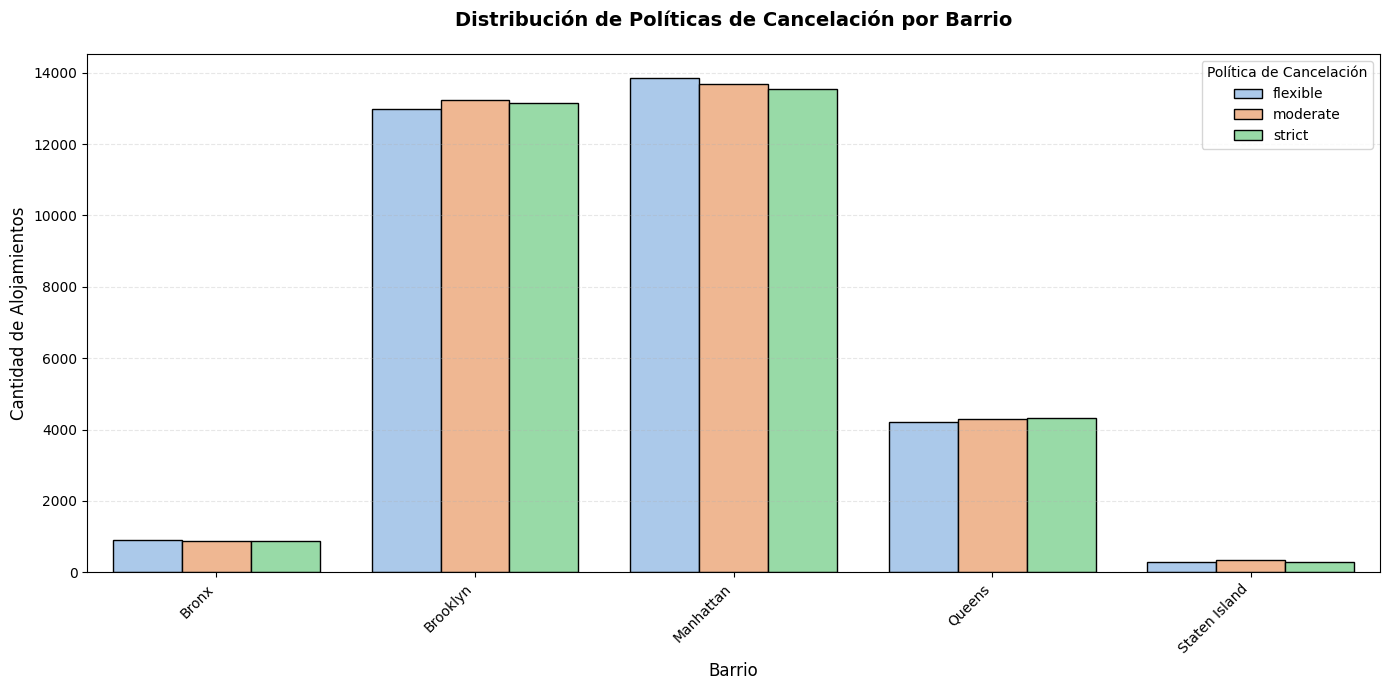


📋 INSIGHT - Políticas de Cancelación:
   • Política más común: moderate (33.5%)


In [13]:
# ============================================================================
# PARTE 3: VISUALIZACIONES COMPARATIVAS ESPECÍFICAS
# ============================================================================

print("\n" + "="*70)
print(" PARTE 3: ANÁLISIS COMPARATIVO Y RELACIONES ".center(70, "="))
print("="*70)

# --- 3.1 Precio Promedio por Barrio (Ordenado) ---
precio_por_barrio = df.groupby('neighbourhood group')['price'].mean().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=precio_por_barrio.values, y=precio_por_barrio.index,
                 palette='viridis', edgecolor='black')

for i, v in enumerate(precio_por_barrio.values):
    ax.text(v + 10, i, f'${v:.0f}', va='center', fontsize=10, fontweight='bold')

plt.title('Precio Promedio por Barrio (Ordenado de Menor a Mayor)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Precio Promedio por Noche (USD)', fontsize=12)
plt.ylabel('Barrio', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🏆 INSIGHT - Ranking de Precios por Barrio:")
print(f"   • Barrio más caro: {precio_por_barrio.index[-1]} (${precio_por_barrio.values[-1]:.2f})")
print(f"   • Barrio más económico: {precio_por_barrio.index[0]} (${precio_por_barrio.values[0]:.2f})")
print(f"   • Diferencia: ${precio_por_barrio.values[-1] - precio_por_barrio.values[0]:.2f}")


# --- 3.2 Número de Reseñas vs Precio (con tendencia) ---
# Filtrar outliers extremos para mejor visualización
df_scatter = df[(df['price'] <= df['price'].quantile(0.95)) &
                (df['number of reviews'] <= df['number of reviews'].quantile(0.95))]

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_scatter, x='price', y='number of reviews',
                hue='room type', alpha=0.5, s=50, palette='Set1', edgecolor='none')
sns.regplot(data=df_scatter, x='price', y='number of reviews',
            scatter=False, color='black', line_kws={'linestyle':'--', 'linewidth':2})

plt.title('Relación entre Precio y Popularidad (Número de Reseñas)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Precio por Noche (USD)', fontsize=12)
plt.ylabel('Número de Reseñas', fontsize=12)
plt.legend(title='Tipo de Habitación', frameon=True)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Calcular correlación
correlation = df['price'].corr(df['number of reviews'])
print(f"\n📈 INSIGHT - Precio vs Popularidad:")
print(f"   • Correlación: {correlation:.3f}")
if abs(correlation) < 0.3:
    print("   • Interpretación: Relación débil - el precio NO determina fuertemente la popularidad")
else:
    print(f"   • Interpretación: Relación {'positiva' if correlation > 0 else 'negativa'} moderada")


# --- 3.3 Política de Cancelación por Barrio ---
# Filtrar solo las políticas principales
politica_barrio = df[df['cancellation_policy'].isin(['flexible', 'moderate', 'strict'])]
politica_counts = politica_barrio.groupby(['neighbourhood group', 'cancellation_policy']).size().reset_index(name='count')

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=politica_counts, x='neighbourhood group', y='count',
                 hue='cancellation_policy', palette='pastel', edgecolor='black')

plt.title('Distribución de Políticas de Cancelación por Barrio', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Barrio', fontsize=12)
plt.ylabel('Cantidad de Alojamientos', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Política de Cancelación', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📋 INSIGHT - Políticas de Cancelación:")
politica_global = df['cancellation_policy'].value_counts()
print(f"   • Política más común: {politica_global.index[0]} ({100*politica_global.values[0]/politica_global.sum():.1f}%)")

# **Parte 4- Análisis Avanzado y Temporal**


========== PARTE 5: ANÁLISIS TEMPORAL Y PATRONES AVANZADOS ===========


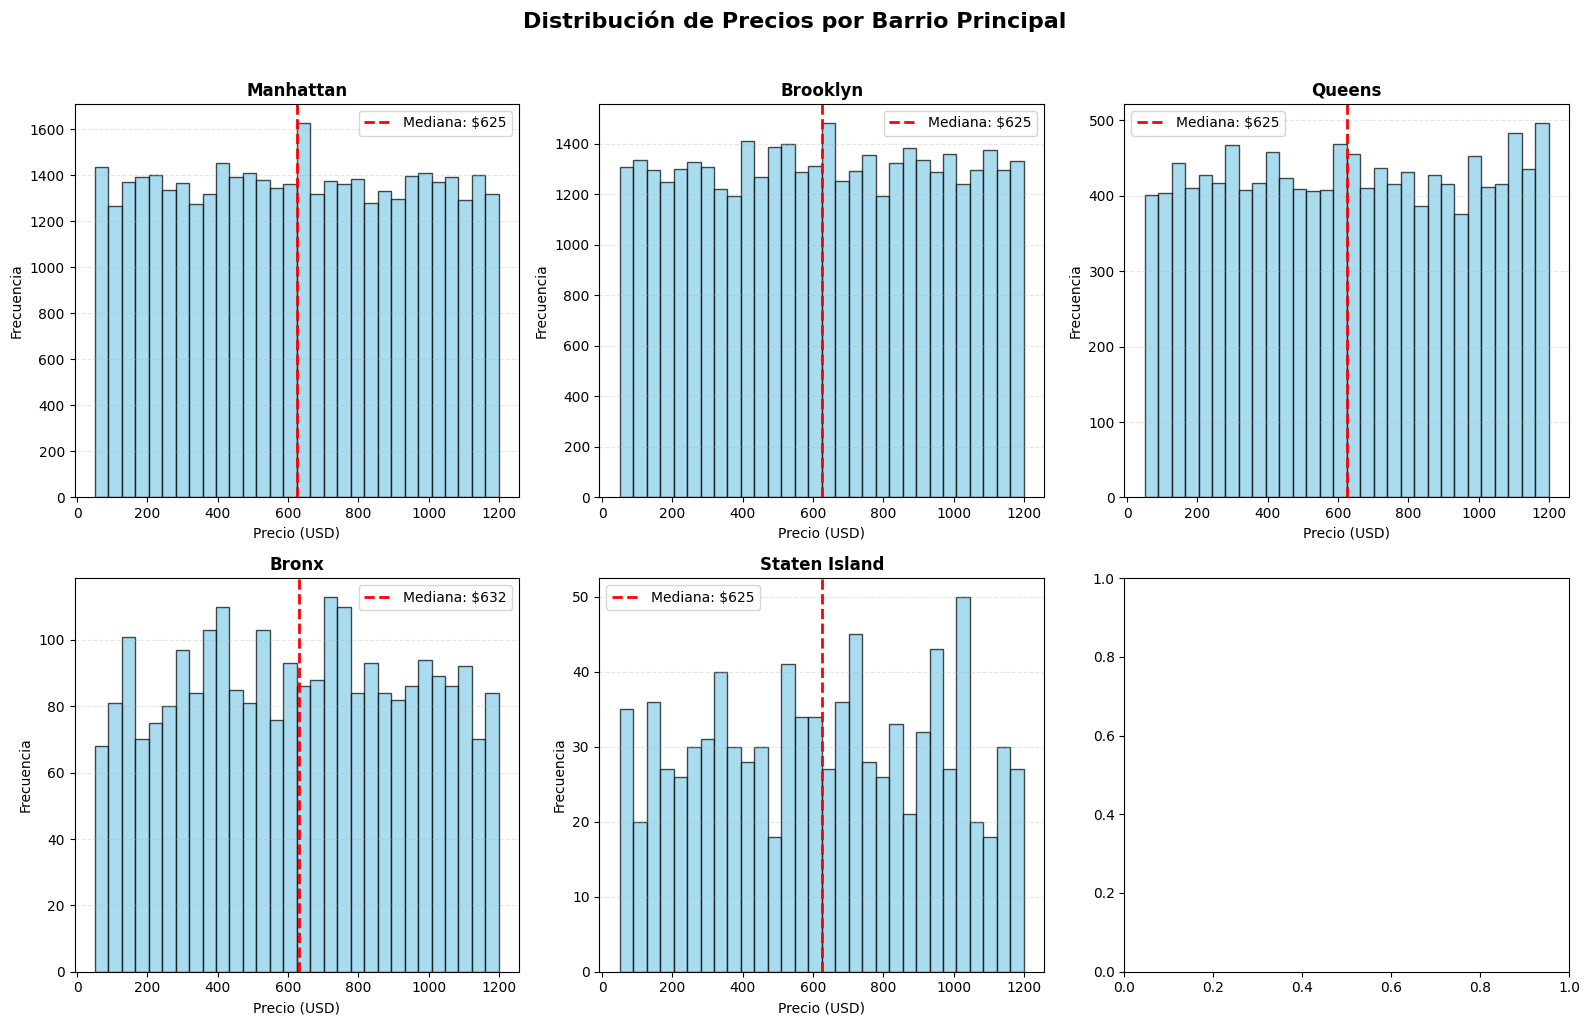

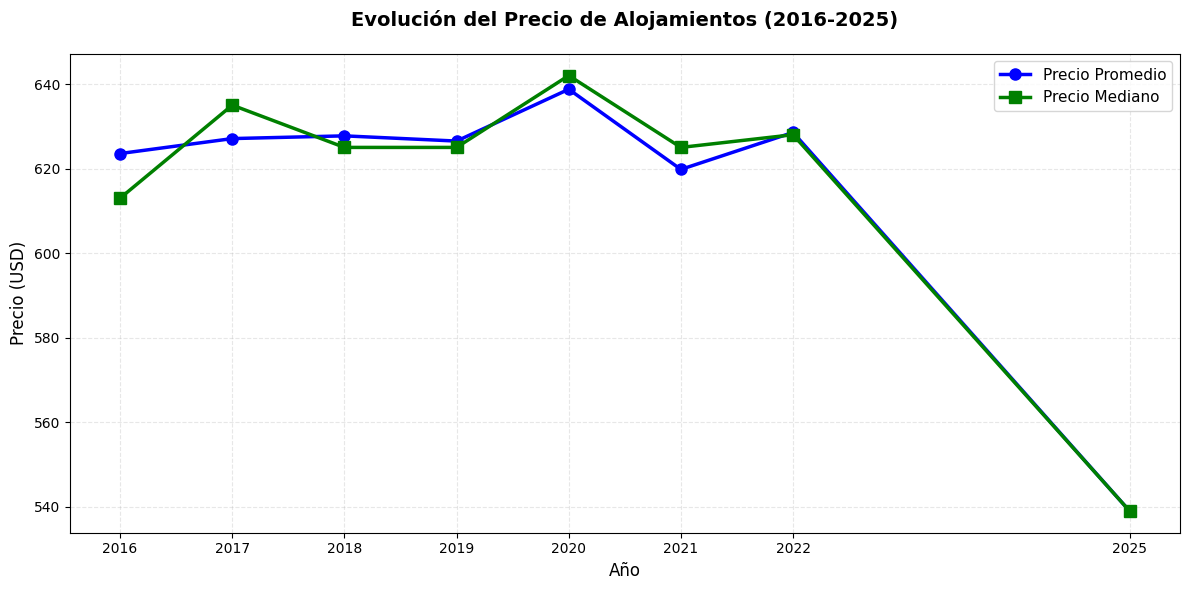


📅 INSIGHT - Evolución Temporal de Precios:
   • Cambio en precio promedio (2016-2025): -13.6%
   • Año con precio más alto: 2020


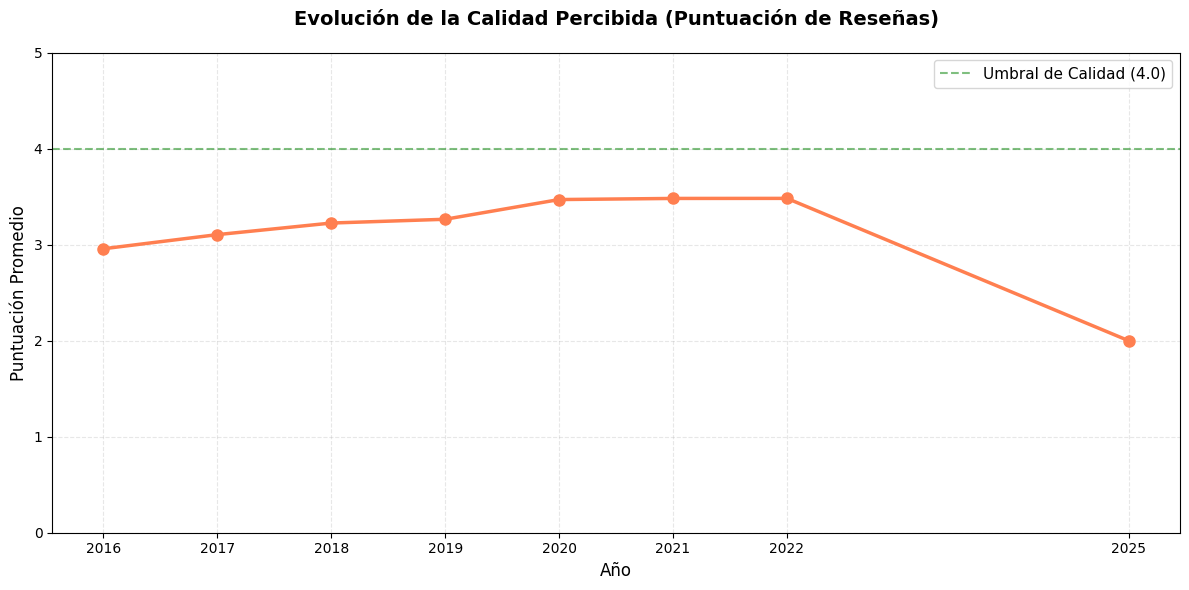


⭐ INSIGHT - Evolución de Calidad:
   • Cambio en puntuación (2016-2025): -0.96 estrellas
   • Puntuación promedio actual: 2.00/5.0


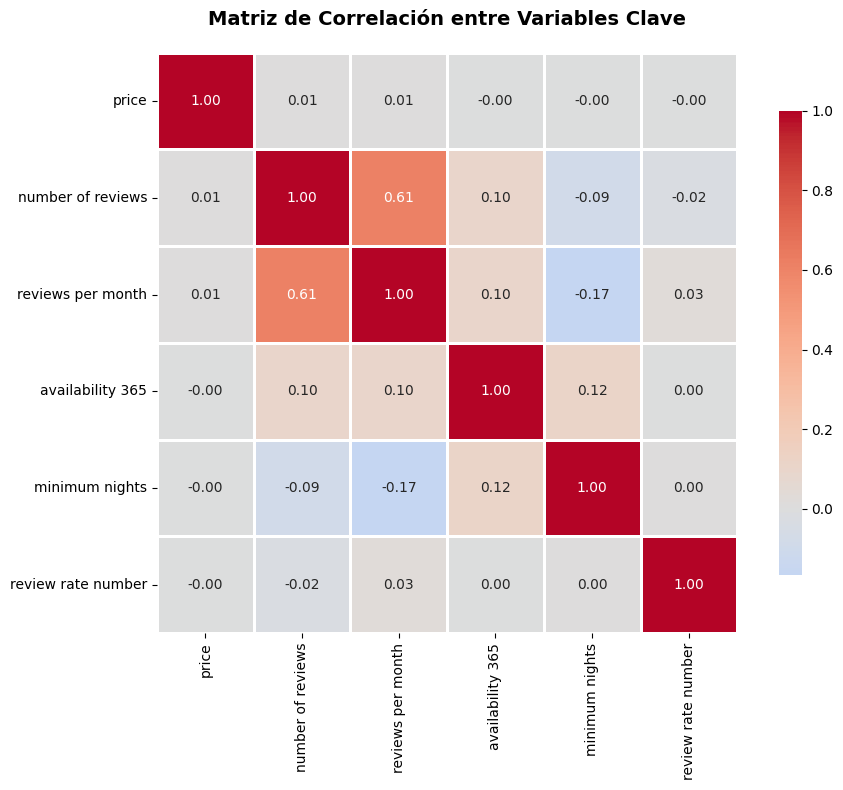


🔗 INSIGHT - Correlaciones Principales:
   • Top 3 correlaciones más fuertes:
     - number of reviews ↔ reviews per month: 0.613
     - reviews per month ↔ minimum nights: -0.167
     - availability 365 ↔ minimum nights: 0.116

====================== FIN DEL ANÁLISIS VISUAL =======================


In [14]:
# ============================================================================
# PARTE 4: ANÁLISIS AVANZADO Y TEMPORAL
# ============================================================================

print("\n" + "="*70)
print(" PARTE 5: ANÁLISIS TEMPORAL Y PATRONES AVANZADOS ".center(70, "="))
print("="*70)

# --- 5.1 Distribución de Precios por Barrio (Facetado) ---
# Seleccionar top 6 barrios para claridad
top_6_neighbourhoods = df['neighbourhood group'].value_counts().head(6).index # Corrected column name
df_top6 = df[df['neighbourhood group'].isin(top_6_neighbourhoods)] # Corrected column name

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, barrio in enumerate(top_6_neighbourhoods):
    data = df_top6[df_top6['neighbourhood group'] == barrio]['price'] # Corrected column name
    axes[idx].hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].axvline(data.median(), color='red', linestyle='--', linewidth=2, label=f'Mediana: ${data.median():.0f}')
    axes[idx].set_title(f'{barrio}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Precio (USD)', fontsize=10)
    axes[idx].set_ylabel('Frecuencia', fontsize=10)
    axes[idx].legend()
    axes[idx].grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Distribución de Precios por Barrio Principal', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# --- 5.2 Evolución Temporal de Precios (Anual) ---
# Re-create 'year' column after filtering if it was dropped
if 'year' not in df.columns and 'last_review' in df.columns:
    df['year'] = df['last_review'].dt.year

# Agrupar por año
precio_anual = df.groupby('year')['price'].agg(['mean', 'median']).reset_index()

plt.figure(figsize=(12, 6))
plt.plot(precio_anual['year'], precio_anual['mean'], marker='o', linewidth=2.5,
         label='Precio Promedio', color='blue', markersize=8)
plt.plot(precio_anual['year'], precio_anual['median'], marker='s', linewidth=2.5,
         label='Precio Mediano', color='green', markersize=8)

plt.title('Evolución del Precio de Alojamientos (2016-2025)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)
plt.legend(fontsize=11, frameon=True)
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(precio_anual['year'].dropna()) # Modified line
plt.tight_layout()
plt.show()

print("\n📅 INSIGHT - Evolución Temporal de Precios:")
# Ensure there are at least two data points for comparison
if len(precio_anual) >= 2:
  cambio_precio = ((precio_anual['mean'].iloc[-1] - precio_anual['mean'].iloc[0]) / precio_anual['mean'].iloc[0]) * 100
  print(f"   • Cambio en precio promedio ({int(precio_anual['year'].min())}-{int(precio_anual['year'].max())}): {cambio_precio:+.1f}%") # Adjusted print
  print(f"   • Año con precio más alto: {int(precio_anual.loc[precio_anual['mean'].idxmax(), 'year'])}") # Adjusted print
else:
  print("   • No hay suficientes años para calcular el cambio de precio.")



# --- 5.3 Evolución de Calidad (Puntuación de Reseñas) ---
df['review rate number'] = pd.to_numeric(df['review rate number'], errors='coerce')
review_anual = df.groupby('year')['review rate number'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(review_anual['year'], review_anual['review rate number'],
         marker='o', linewidth=2.5, color='coral', markersize=8)

plt.title('Evolución de la Calidad Percibida (Puntuación de Reseñas)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Puntuación Promedio', fontsize=12)
plt.ylim(0, 5)
plt.axhline(y=4, color='green', linestyle='--', alpha=0.5, label='Umbral de Calidad (4.0)')
plt.legend(fontsize=11, frameon=True)
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(review_anual['year'].dropna()) # Modified line
plt.tight_layout()
plt.show()

print("\n⭐ INSIGHT - Evolución de Calidad:")
# Ensure there are at least two data points for comparison
if len(review_anual) >= 2:
    cambio_calidad = review_anual['review rate number'].iloc[-1] - review_anual['review rate number'].iloc[0]
    print(f"   • Cambio en puntuación ({int(review_anual['year'].min())}-{int(review_anual['year'].max())}): {cambio_calidad:+.2f} estrellas") # Adjusted print
    print(f"   • Puntuación promedio actual: {review_anual['review rate number'].iloc[-1]:.2f}/5.0")
else:
    print("   • No hay suficientes años para calcular el cambio de calidad.")


# --- 5.4 Mapa de Calor: Correlaciones entre Variables Clave ---
# Seleccionar variables numéricas relevantes
vars_correlacion = ['price', 'number of reviews', 'reviews per month',
                    'availability 365', 'minimum nights', 'review rate number']
correlacion_matrix = df[vars_correlacion].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlacion_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})

plt.title('Matriz de Correlación entre Variables Clave', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n🔗 INSIGHT - Correlaciones Principales:")
# Encontrar las correlaciones más fuertes (excluyendo diagonal)
corr_pairs = []
for i in range(len(correlacion_matrix.columns)):
    for j in range(i+1, len(correlacion_matrix.columns)):
        corr_pairs.append((correlacion_matrix.columns[i],
                          correlacion_matrix.columns[j],
                          correlacion_matrix.iloc[i, j]))

corr_pairs_sorted = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)
print("   • Top 3 correlaciones más fuertes:")
for var1, var2, corr in corr_pairs_sorted[:3]:
    print(f"     - {var1} ↔ {var2}: {corr:.3f}")


print("\n" + "="*70)
print(" FIN DEL ANÁLISIS VISUAL ".center(70, "="))
print("="*70)

# **Análisis Predictivo de Precios para Alojamientos de Airbnb en Nueva York – Parte II**

# **Abstract**

Este proyecto analiza el mercado de alquileres temporales de Airbnb en Nueva York, utilizando el dataset público *“Airbnb_Open_Dataset_Oficial.csv”*. El objetivo principal es desarrollar un modelo de Machine Learning capaz de predecir el precio por noche de un alojamiento, identificando los factores que más influyen en su valor.

El análisis incluye un riguroso pipeline de limpieza de datos, ingeniería de características **(con 7 variables nuevas, incluyendo antigüedad de la propiedad y presencia de servicios clave)**, y entrenamiento de modelos de regresión. El modelo final, un RandomForestRegressor, alcanzó un coeficiente de determinación R² = 0.325, superando ampliamente a un modelo lineal de base.

El estudio demuestra que ubicación geográfica **(latitud y longitud)** y disponibilidad anual son los predictores más relevantes, mientras que variables creadas, como la antigüedad de la propiedad, también aportan valor predictivo. Aunque el modelo ofrece una herramienta útil para estimar precios, su precisión puede mejorar incorporando información más detallada sobre servicios, calidad de la propiedad y reseñas.

# **Objetivo y Problema**

En el competitivo mercado de Airbnb, fijar un precio adecuado es crucial: los anfitriones buscan maximizar rentabilidad, mientras los huéspedes desean evaluar si una tarifa es justa.

# *El problema central radica en la falta de referencias objetivas de precios.* **Por ello, este proyecto busca:**

Construir un modelo de regresión que prediga el precio de un alojamiento en Nueva York.

Ayudar a los anfitriones a posicionar sus propiedades con precios competitivos.

Permitir a los huéspedes evaluar la adecuación del precio de un listado.

Identificar los atributos que más impactan en el valor de un alojamiento.

# **Hipótesis**

# **El análisis se enfocó en evaluar las siguientes hipótesis mediante *EDA* y modelado:**

# *Hipótesis de Ubicación:*
El distrito **(neighborhood_group)** y la ubicación exacta **(lat, long)** determinan la mayor parte de la variación en precios.
Resultado: Confirmada. Latitud y longitud fueron las variables más importantes según Random Forest.

# *Hipótesis de Tipo de Propiedad:*
El tipo de habitación **(room_type)** impacta directamente en el precio.
Resultado: Confirmada. Ser una “Private room” se posiciona entre las 10 características más influyentes.

# *Hipótesis de Valor Añadido:*
La creación de nuevas variables mejorará la precisión predictiva.
Resultado: Confirmada. La variable antiguedad_propiedad fue la quinta más relevante, mientras que tiene_cocina también contribuyó aunque en menor medida.

In [15]:
# 1. Configuración de las Librerías
import seaborn as sns
import shap
import math

# 1.1. Librerías de Scikit-Learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline

# 1.2. Configuración de visualizaciones
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("1. Librerías cargadas exitosamente")

1. Librerías cargadas exitosamente


In [16]:
try:
    url = 'https://raw.githubusercontent.com/IturryCamila/Data-Science-Camila-Iturry/refs/heads/main/Airbnb_Open_Data.csv'
    df = pd.read_csv(url, low_memory=False)  # SIN sep=';'
    print("Dataset cargado desde URL")
    print(f"Shape: {df.shape}")
except Exception as e:
    print(f"Error al cargar: {e}")
    df = None # Ensure df is None if loading fails

# 2.6 Continuar solo si el DataFrame se cargó con éxito
if df is not None:
    print("2.3 \n--- Vistazo Inicial al Dataset ---")
    print(f"2.3.1 Dimensiones iniciales: {df.shape}")
    print("2.3.2 \nPrimeras 3 filas:")
    display(df.head(3))
    print("2.3.4 \nInformación general del DataFrame:")
    df.info()
else:
    print("2.3.5 \nEl DataFrame no pudo ser cargado. No se puede proceder con el análisis.")

Dataset cargado desde URL
Shape: (102599, 26)
2.3 
--- Vistazo Inicial al Dataset ---
2.3.1 Dimensiones iniciales: (102599, 26)
2.3.2 
Primeras 3 filas:


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN


2.3.4 
Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                1024

In [17]:
# 3. Limpieza y Preprocesamiento de Datos
print("3. Iniciando el pipeline de Limpieza y Preprocesamiento")

if 'df' in locals() and df is not None:

    # PASO 1: ESTANDARIZACIÓN INICIAL
    print("\n 3.1 - Estandarizando nombres y valores")
    df.columns = df.columns.str.replace(' ', '_').str.lower()
    df.rename(columns={'neighbourhood_group': 'neighborhood_group'}, inplace=True)
    df.replace(['unconfirmed', 'Unspecified', 'NA', '#NAME?', ''], np.nan, inplace=True)

    # PASO 2: CONVERSIÓN DE TIPOS
    print(" 3.2 - Convirtiendo tipos de datos")
    # Convert price and service fee to numeric first
    for col in ['price', 'service_fee']:
        if col in df.columns:
            # Remove '$' and ',' and convert to numeric
            df[col] = df[col].astype(str).str.replace('[$,]', '', regex=True).str.strip()
            df[col] = pd.to_numeric(df[col], errors='coerce')

    if 'last_review' in df.columns:
        df['last_review'] = pd.to_datetime(df['last_review'], format='%m/%d/%Y', errors='coerce')


    # PASO 3: LÓGICA DE PRECIOS Y FILTRADO
    print(" 3.3 - Aplicando lógica de negocio y filtrando precios")
    condition = (df['price'] == 0) & (df['service_fee'] > 0)
    df['price'] = np.where(condition, df['service_fee'], df['price'])
    df.dropna(subset=['price'], inplace=True)
    df = df[df['price'] > 0]
    limite_superior = 1200
    df = df[df['price'] <= limite_superior].copy()

    # PASO 4: LIMPIEZA DE DISTRITOS (CREACIÓN DE 'distritos')
    print(" 3.4 - Corrigiendo columna de distritos")
    distritos_validos = ['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx']
    df_confiable = df[df['neighborhood_group'].isin(distritos_validos)].copy()
    mapa_barrio_a_distrito = df_confiable.drop_duplicates(subset='neighbourhood').set_index('neighbourhood')['neighborhood_group'].to_dict()
    def corregir_distrito(row):

        distrito_actual, barrio_actual = row['neighborhood_group'], row['neighbourhood']
        if distrito_actual in distritos_validos: return distrito_actual
        if distrito_actual in mapa_barrio_a_distrito: return mapa_barrio_a_distrito[distrito_actual]
        if barrio_actual in mapa_barrio_a_distrito: return mapa_barrio_a_distrito[barrio_actual]
        return 'Desconocido'
    df['distritos'] = df.apply(corregir_distrito, axis=1)

    # PASO 5: LIMPIEZA DE HOST IDENTITY
    print(" 3.5 - Limpiando columna 'host_identity_verified'")
    if 'host_identity_verified' in df.columns:
        df.loc[df['host_identity_verified'] != 'verified', 'host_identity_verified'] = 'unconfirmed'

    # === PASO 6: IMPUTACIÓN DE NULOS (INCLUYENDO TEXTO Y COORDENADAS)
    print(" 3.6 - Imputando nulos restantes")
    # Imputar texto con ''
    for col in ['publicity', 'house_rules']:
        if col in df.columns: df[col] = df[col].fillna('')
    # Imputar coordenadas con la mediana del distrito
    for coord in ['lat', 'long']:
        if coord in df.columns:
            df[coord] = df[coord].replace(0, np.nan)
            df[coord] = df[coord].fillna(df.groupby('distritos')[coord].transform('median'))
            df[coord] = df[coord].fillna(df[coord].median())
    # Imputar el resto
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['int64', 'float64']:
                df[col] = df[col].fillna(df[col].median())
            else:
                df[col] = df[col].fillna(df[col].mode()[0])

    # PASO 3.7: VERIFICACIÓN FINAL
    nulos_finales = df.isnull().sum().sum()
    print(f"\n3.7  Limpieza completada. Total de nulos restantes: {nulos_finales} ")
    if nulos_finales == 0:
        print("3.8 DataFrame 'df' listo para las siguientes secciones")
        print(f"3.9 Dimensiones finales de df: {df.shape}")
        print("3.10 Verificación: 'distritos' está en las columnas:", 'distritos' in df.columns)
    else:
        print("3.11 ADVERTENCIA: Aún quedan nulos.")
else:
    print("\n3.12 Error: El DataFrame no fue cargado.")

3. Iniciando el pipeline de Limpieza y Preprocesamiento

 3.1 - Estandarizando nombres y valores
 3.2 - Convirtiendo tipos de datos
 3.3 - Aplicando lógica de negocio y filtrando precios
 3.4 - Corrigiendo columna de distritos
 3.5 - Limpiando columna 'host_identity_verified'
 3.6 - Imputando nulos restantes

3.7  Limpieza completada. Total de nulos restantes: 0 
3.8 DataFrame 'df' listo para las siguientes secciones
3.9 Dimensiones finales de df: (102352, 27)
3.10 Verificación: 'distritos' está en las columnas: True


/tmp/ipython-input-202384714.py:70: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


## Exploración de Datos (EDA)
La exploración de datos se realizó previamente en la Parte I del proyecto. Los principales hallazgos relevantes para el modelado incluyen:
- Distribución de precios concentrada < $500, con outliers filtrados (> $1200)
- Manhattan y Brooklyn muestran los precios más altos
- Tipo de propiedad impacta: Entire home/apt > Private room > Shared room
- Latitud/longitud y disponibilidad anual correlacionan con precio


## 5. Propuesta de Modelado Analítico

Tras la limpieza y exploración de datos, se procede a la fase de modelado para predecir el precio de los alojamientos.

**Tipo de Aprendizaje:** Regresión Supervisada  
El problema es supervisado, ya que contamos con un dataset histórico donde cada alojamiento tiene características y un valor objetivo conocido (*price*). Es una tarea de regresión, dado que la variable objetivo es numérica continua.

**Modelos a evaluar:**

1. **Modelo Baseline: Regresión Lineal (LinearRegression)**  
   - **Justificación:** Simple y fácilmente interpretable. Permite cuantificar cómo cada característica impacta el precio y sirve de referencia para medir mejoras de modelos más complejos.  
   - **Preprocesamiento:** Normalización de variables numéricas y codificación de variables categóricas.

2. **Modelo Principal: Random Forest Regressor (RandomForestRegressor)**  
   - **Justificación:** Captura relaciones no lineales y complejas, es robusto ante outliers y puede manejar gran cantidad de variables.  
   - **Preprocesamiento:** Codificación de variables categóricas; no requiere escalado.  
   - **Validación:** Se aplicará train/test split y validación cruzada; optimización de hiperparámetros mediante GridSearchCV.  
   - **Interpretación:** Se evaluará la importancia de variables para confirmar hipótesis planteadas en el EDA.

**Evaluación de modelos:**  
Se comparará el desempeño utilizando métricas estándar de regresión: Coeficiente de Determinación (R²) y Error Cuadrático Medio Raíz (RMSE). Esto permitirá determinar si el modelo principal ofrece mejoras significativas respecto al baseline.


In [18]:
# ==========================
# 6. INGENIERÍA DE CARACTERÍSTICAS
# ==========================
print("6. Iniciando Ingeniería de Características")

if 'df' in locals() and df is not None:
    df_featured = df.copy()

    # 6.1 Antigüedad de la propiedad
    if 'construction_year' in df_featured.columns:
        current_year = pd.Timestamp.now().year
        df_featured['antiguedad_propiedad'] = np.where(
            (pd.notnull(df_featured['construction_year'])) & (df_featured['construction_year'] > 0),
            current_year - df_featured['construction_year'],
            np.nan
        )
        print(f"✓ antiguedad_propiedad creada (mean: {df_featured['antiguedad_propiedad'].mean():.1f} años)")

    # 6.2 Anfitrión experimentado
    if 'calculated_host_listings_count' in df_featured.columns:
        df_featured['anfitrion_experimentado'] = np.where(
            df_featured['calculated_host_listings_count'] > 3, 1, 0
        ).astype(int)
        print(f"✓ anfitrion_experimentado creada ({df_featured['anfitrion_experimentado'].sum():,} hosts)")

    print("\n✓ Feature Engineering completado: 2 nuevas variables creadas")
    display(df_featured[['antiguedad_propiedad', 'anfitrion_experimentado']].head())
else:
    print("Error: df no existe.")


6. Iniciando Ingeniería de Características
✓ antiguedad_propiedad creada (mean: 12.5 años)
✓ anfitrion_experimentado creada (17,767 hosts)

✓ Feature Engineering completado: 2 nuevas variables creadas


,antiguedad_propiedad,anfitrion_experimentado
0,5.0,1
1,18.0,0
2,20.0,0
3,20.0,0
4,16.0,0


In [20]:
# ==========================
# 6. INGENIERÍA DE CARACTERÍSTICAS
# ==========================
print("6. Iniciando Ingeniería de Características")

if 'df' in locals() and df is not None:
    df_featured = df.copy()

    # 6.1 Antigüedad de la propiedad
    if 'construction_year' in df_featured.columns:
        current_year = pd.Timestamp.now().year
        df_featured['antiguedad_propiedad'] = np.where(
            (pd.notnull(df_featured['construction_year'])) & (df_featured['construction_year'] > 0),
            current_year - df_featured['construction_year'],
            np.nan
        )
        # Impute NaN values in 'antiguedad_propiedad' after calculation
        df_featured['antiguedad_propiedad'] = df_featured['antiguedad_propiedad'].fillna(df_featured['antiguedad_propiedad'].median())
        print(f"✓ antiguedad_propiedad creada (mean: {df_featured['antiguedad_propiedad'].mean():.1f} años)")

    # 6.2 Anfitrión experimentado
    if 'calculated_host_listings_count' in df_featured.columns:
        df_featured['anfitrion_experimentado'] = np.where(
            df_featured['calculated_host_listings_count'] > 3, 1, 0
        ).astype(int)
        print(f"✓ anfitrion_experimentado creada ({df_featured['anfitrion_experimentado'].sum():,} hosts)")

    # 6.3 Creación de features de Amenities (basado en texto)
    print(" 6.3 - Creando features de Amenities")
    df_featured['tiene_wifi'] = df_featured['house_rules'].fillna('').astype(str).str.contains('wifi', case=False, na=False).astype(int)
    df_featured['tiene_cocina'] = df_featured['house_rules'].fillna('').astype(str).str.contains('kitchen|cocina', case=False, na=False).astype(int)
    df_featured['tiene_ac'] = df_featured['house_rules'].fillna('').astype(str).str.contains('ac|air condition', case=False, na=False).astype(int)
    df_featured['apto_mascotas'] = df_featured['house_rules'].fillna('').astype(str).str.contains('pet|mascota', case=False, na=False).astype(int)
    df_featured['tiene_parking'] = df_featured['house_rules'].fillna('').astype(str).str.contains('parking|estacionamiento', case=False, na=False).astype(int)
    print("✓ Features de Amenities creadas")


    # 6.4 Nuevas features descriptivas
    amenities_cols = ['tiene_wifi','tiene_cocina','tiene_ac','apto_mascotas','tiene_parking']
    # Ensure only existing columns are used for sum
    existing_amenities_cols = [col for col in amenities_cols if col in df_featured.columns]
    if existing_amenities_cols:
        df_featured['total_amenities'] = df_featured[existing_amenities_cols].sum(axis=1)
        print("✓ total_amenities creada")
    else:
        df_featured['total_amenities'] = 0 # Or handle appropriately if no amenity columns exist
        print("⚠️ No se crearon columnas de amenities, 'total_amenities' se estableció en 0")


    if 'reviews_per_month' in df_featured.columns and 'number_of_reviews' in df_featured.columns:
      df_featured['recent_reviews'] = df_featured['reviews_per_month'].fillna(0) * df_featured['number_of_reviews'].fillna(0)
      print("✓ recent_reviews creada")
    else:
      # Handle case where reviews columns might be missing
      df_featured['recent_reviews'] = 0
      print("⚠️ Columnas de reseñas no encontradas, 'recent_reviews' se estableció en 0")


    print("\n✓ Feature Engineering completado")
    display(df_featured[['antiguedad_propiedad', 'anfitrion_experimentado', 'tiene_wifi', 'tiene_cocina', 'tiene_ac', 'apto_mascotas', 'tiene_parking', 'total_amenities', 'recent_reviews']].head())

else:
    print("Error: df no existe.")

6. Iniciando Ingeniería de Características
✓ antiguedad_propiedad creada (mean: 12.5 años)
✓ anfitrion_experimentado creada (17,767 hosts)
 6.3 - Creando features de Amenities
✓ Features de Amenities creadas
✓ total_amenities creada
✓ recent_reviews creada

✓ Feature Engineering completado


,antiguedad_propiedad,anfitrion_experimentado,tiene_wifi,tiene_cocina,tiene_ac,apto_mascotas,tiene_parking,total_amenities,recent_reviews
0,5.0,1,0,0,0,0,0,0,1.89
1,18.0,0,0,0,1,1,0,2,17.10
2,20.0,0,0,1,1,0,0,2,0.00
3,20.0,0,0,0,0,0,0,0,1252.80
4,16.0,0,0,0,0,0,0,0,0.90


In [21]:
# ==========================
# 7. PREPARACIÓN FINAL PARA EL MODELADO
# ==========================
print("\n7. Definiendo X y y")

# 7.1 Filtrado de outliers en price
q_low = df_featured['price'].quantile(0.01)
q_high = df_featured['price'].quantile(0.99)
df_featured = df_featured[(df_featured['price'] >= q_low) & (df_featured['price'] <= q_high)]
print(f"✓ Filtrado de outliers en 'price': {df_featured.shape[0]} registros restantes")

# 7.2 Selección de columnas
columnas_a_conservar = [
    'host_identity_verified', 'lat', 'long', 'calculated_host_listings_count',
    'instant_bookable', 'availability_365', 'cancellation_policy', 'room_type',
    'minimum_nights', 'number_of_reviews', 'review_rate_number', 'distritos',
    'antiguedad_propiedad', 'anfitrion_experimentado', 'tiene_wifi',
    'tiene_cocina', 'tiene_ac', 'apto_mascotas', 'tiene_parking',
    'total_amenities', 'recent_reviews'
]

columnas_existentes_en_df = [col for col in columnas_a_conservar if col in df_featured.columns]
X = df_featured[columnas_existentes_en_df].copy()
y = df_featured['price']

# 7.3 Conversión de columnas numéricas
columnas_numericas = [
    'lat', 'long', 'calculated_host_listings_count', 'availability_365',
    'minimum_nights', 'number_of_reviews', 'review_rate_number', 'antiguedad_propiedad',
    'total_amenities', 'recent_reviews'
]
for col in columnas_numericas:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')

# 7.4 Reescalado de coordenadas si son anómalas
factor_escala = 1e8
X['lat'] = X['lat'].apply(lambda x: x / factor_escala if abs(x) > 90 else x)
X['long'] = X['long'].apply(lambda x: x / factor_escala if abs(x) > 180 else x)
print("✓ Coordenadas 'lat' y 'long' reescaladas")

display(X.head())



7. Definiendo X y y
✓ Filtrado de outliers en 'price': 100381 registros restantes
✓ Coordenadas 'lat' y 'long' reescaladas


,host_identity_verified,lat,long,calculated_host_listings_count,instant_bookable,availability_365,cancellation_policy,room_type,minimum_nights,number_of_reviews,...,distritos,antiguedad_propiedad,anfitrion_experimentado,tiene_wifi,tiene_cocina,tiene_ac,apto_mascotas,tiene_parking,total_amenities,recent_reviews
0,unconfirmed,40.64749,-73.97237,6.0,False,286.0,strict,Private room,10.0,9.0,...,Brooklyn,5.0,1,0,0,0,0,0,0,1.89
1,verified,40.75362,-73.98377,2.0,False,228.0,moderate,Entire home/apt,30.0,45.0,...,Manhattan,18.0,0,0,0,1,1,0,2,17.10
2,unconfirmed,40.80902,-73.94190,1.0,True,352.0,flexible,Private room,3.0,0.0,...,Manhattan,20.0,0,0,1,1,0,0,2,0.00
3,unconfirmed,40.68514,-73.95976,1.0,True,322.0,moderate,Entire home/apt,30.0,270.0,...,Brooklyn,20.0,0,0,0,0,0,0,0,1252.80
4,verified,40.79851,-73.94399,1.0,False,289.0,moderate,Entire home/apt,10.0,9.0,...,Manhattan,16.0,0,0,0,0,0,0,0,0.90


In [22]:
# ==========================
# 8. CODIFICACIÓN Y DIVISIÓN DE DATOS
# ==========================
categorical_cols = ['host_identity_verified', 'cancellation_policy', 'room_type', 'distritos']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

# División en train y test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


9. Entrenamiento y evaluación
RMSE: $336.82, R²: -0.0750, MAE: $285.64, MAPE: 75.03%
Media residuales: $113.36, Desv. estándar: $317.18


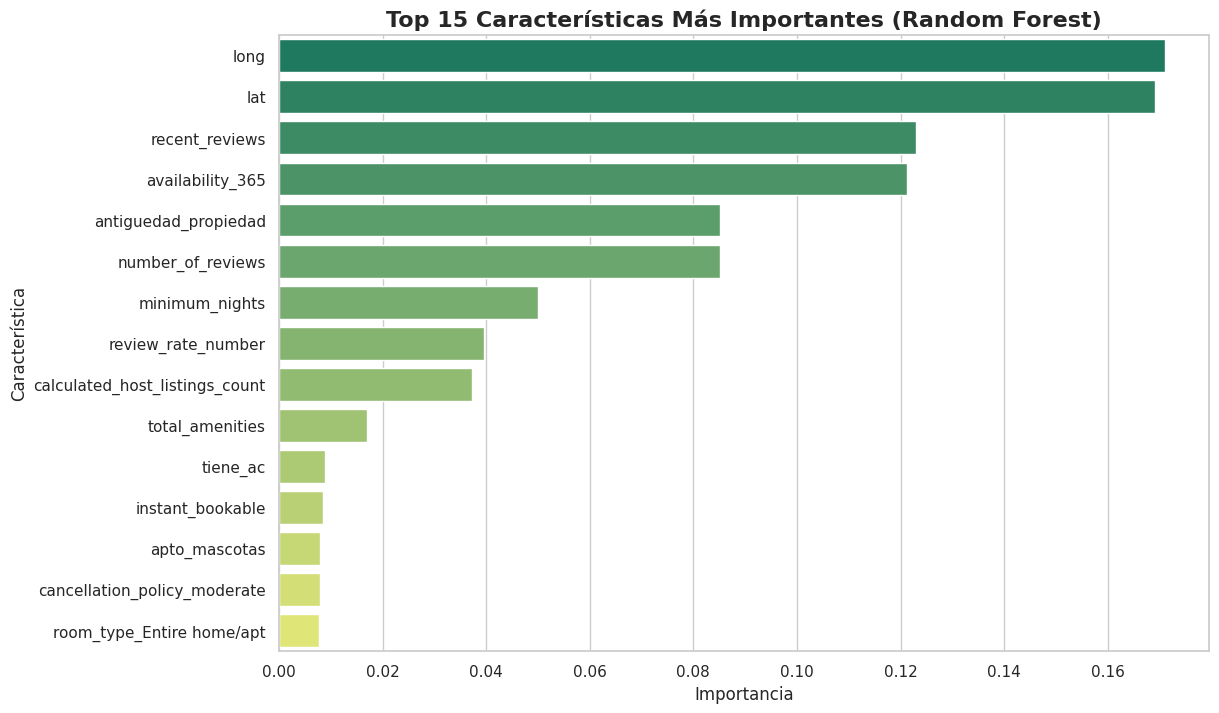

In [24]:
# ==========================
# 9. MODELADO Y EVALUACIÓN
# ==========================
print("\n9. Entrenamiento y evaluación")

# One-Hot Encoding for categorical features
categorical_cols = ['host_identity_verified', 'cancellation_policy', 'room_type', 'distritos']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False) # Ensure this matches the columns used in X_train/X_test

# Log-transformación para manejar skew
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Random Forest mejorado
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=15, random_state=42, n_jobs=-1, oob_score=True
)

# Split the encoded data
X_train_encoded, X_test_encoded, _, _ = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


rf_model.fit(X_train_encoded, y_train_log)

# Predicciones y métricas
y_pred_rf_log = rf_model.predict(X_test_encoded)
y_pred_rf = np.expm1(y_pred_rf_log)  # Volver a escala original

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

print(f"RMSE: ${rmse_rf:.2f}, R²: {r2_rf:.4f}, MAE: ${mae_rf:.2f}, MAPE: {mape_rf:.2f}%")
residuales = y_test - y_pred_rf
print(f"Media residuales: ${residuales.mean():.2f}, Desv. estándar: ${residuales.std():.2f}")

# Importancia de features
feature_importances = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(
    x='importance',
    y='feature',
    data=feature_importances.head(15),
    hue='feature',
    legend=False,
    palette='summer'
)
plt.title('Top 15 Características Más Importantes (Random Forest)', fontsize=16, fontweight='bold')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.show()

In [27]:
# ==========================
# 10 FUNCIONES CASO DE USO
# ==========================
def predecir_precio(modelo, datos, columnas_ref):
    """
    Recibe:
      - modelo entrenado
      - datos: diccionario con features en formato original (antes de one-hot encoding)
      - columnas_ref: columnas originales de entrenamiento (antes de one-hot encoding)
    Devuelve:
      - Predicción en escala original ($)
    """
    # Convertir a DataFrame
    df_input = pd.DataFrame([datos])

    # Identificar columnas categóricas (deben coincidir con las usadas en el entrenamiento)
    categorical_cols = ['host_identity_verified', 'cancellation_policy', 'room_type', 'distritos']

    # Aplicar One-Hot Encoding al DataFrame de entrada
    df_input_encoded = pd.get_dummies(df_input, columns=categorical_cols, drop_first=False)

    # Asegurar que el DataFrame de entrada tenga las mismas columnas que el entrenamiento
    # Rellenar con 0s las columnas que faltan y reordenar
    df_input_aligned = df_input_encoded.reindex(columns=columnas_ref, fill_value=0)


    return np.expm1(modelo.predict(df_input_aligned))[0]


# Construir ejemplo de anfitrión (usando nombres de columnas originales)
datos_anfitrion = {
    'lat': 40.78,
    'long': -73.96,
    'calculated_host_listings_count': 1,
    'availability_365': 150,
    'minimum_nights': 3,
    'number_of_reviews': 15,
    'review_rate_number': 4.5,
    'antiguedad_propiedad': 10,
    'anfitrion_experimentado': 0,
    'tiene_wifi': 1,
    'tiene_cocina': 1,
    'tiene_ac': 1,
    'apto_mascotas': 0,
    'tiene_parking': 0,
    'total_amenities': 3, # Suma de tiene_wifi, tiene_cocina, tiene_ac, apto_mascotas, tiene_parking
    'recent_reviews': 15 * 0.5, # Assuming reviews per month is 0.5 for this example
    'host_identity_verified': 'verified',
    'instant_bookable': True, # Assuming True for instant bookable
    'cancellation_policy': 'flexible',
    'room_type': 'Entire home/apt',
    'distritos': 'Manhattan'
}

# Obtener las columnas del DataFrame X antes del one-hot encoding
columnas_originales_X = X.columns.tolist()

precio_predicho_rf = predecir_precio(rf_model, datos_anfitrion, X_train_encoded.columns)
print("\n10. Simulación para el Anfitrión")
print(f"Precio estimado por el modelo: ${precio_predicho_rf:.2f}")


# Construir ejemplo de huésped (usando nombres de columnas originales)
datos_huesped = {
    'lat': 40.69,
    'long': -73.98,
    'calculated_host_listings_count': 2,
    'availability_365': 300,
    'minimum_nights': 2,
    'number_of_reviews': 50,
    'review_rate_number': 4.8,
    'antiguedad_propiedad': 5,
    'anfitrion_experimentado': 0,
    'tiene_wifi': 1,
    'tiene_cocina': 0,
    'tiene_ac': 1,
    'apto_mascotas': 0,
    'tiene_parking': 1,
    'total_amenities': 3, # Suma de tiene_wifi, tiene_cocina, tiene_ac, apto_mascotas, tiene_parking
    'recent_reviews': 50 * 0.8, # Assuming reviews per month is 0.8 for this example
    'host_identity_verified': 'verified',
    'instant_bookable': False, # Assuming False for instant bookable
    'cancellation_policy': 'moderate',
    'room_type': 'Private room',
    'distritos': 'Brooklyn'
}

precio_referencia_rf = predecir_precio(rf_model, datos_huesped, X_train_encoded.columns)
print("\n11. Simulación para el Huésped")
print(f"Precio de referencia estimado por el modelo: ${precio_referencia_rf:.2f}")


10. Simulación para el Anfitrión
Precio estimado por el modelo: $518.98

11. Simulación para el Huésped
Precio de referencia estimado por el modelo: $487.01


12. Analizando la relación entre Oferta, Demanda y % Ocupación en los barrios principales


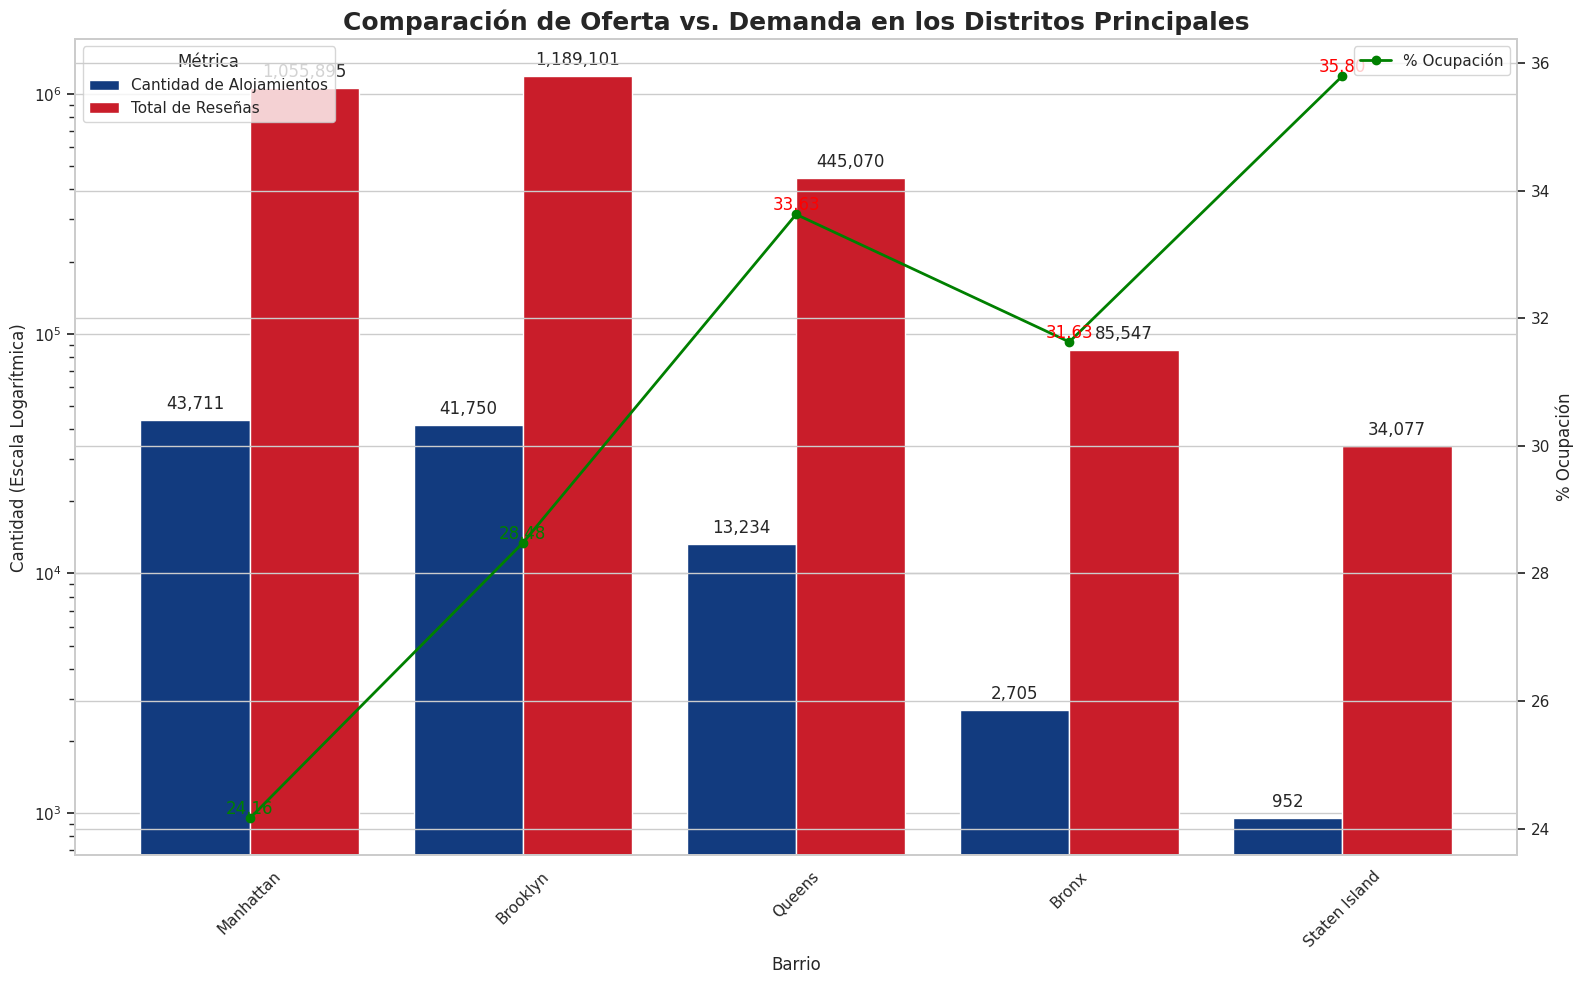

In [28]:
# ==========================
# 11. ANÁLISIS OFERTA VS DEMANDA Y % OCUPACIÓN
# ==========================
print("12. Analizando la relación entre Oferta, Demanda y % Ocupación en los barrios principales")

if 'df' in locals() and 'distritos' in df.columns and 'number_of_reviews' in df.columns:

    # Oferta y Demanda
    oferta_barrios = df['distritos'].value_counts().rename('Cantidad de Alojamientos')
    demanda_barrios = df.groupby('distritos')['number_of_reviews'].sum().rename('Total de Reseñas')

    df_comparativo = pd.concat([oferta_barrios, demanda_barrios], axis=1)
    df_comparativo['% Ocupación'] = (df_comparativo['Total de Reseñas'] / df_comparativo['Cantidad de Alojamientos']).round(2)

    # Top 10 barrios (o todos si hay menos)
    df_top10 = df_comparativo.sort_values('Cantidad de Alojamientos', ascending=False).head(10)

    # Melt para barras
    df_melted = df_top10.reset_index().melt(
        id_vars='distritos',
        value_vars=['Cantidad de Alojamientos', 'Total de Reseñas'],
        var_name='Metrica',
        value_name='Valor'
    )
    df_melted['Valor'] = pd.to_numeric(df_melted['Valor'], errors='coerce')

    # Gráfico
    fig, ax1 = plt.subplots(figsize=(16,10))

    sns.barplot(
        data=df_melted,
        x='distritos',
        y='Valor',
        hue='Metrica',
        palette={'Cantidad de Alojamientos':'#003791', 'Total de Reseñas':'#E60012'},
        ax=ax1
    )

    ax1.set_yscale('log')
    ax1.set_xlabel('Barrio', fontsize=12)
    ax1.set_ylabel('Cantidad (Escala Logarítmica)', fontsize=12)
    ax1.set_title('Comparación de Oferta vs. Demanda en los Distritos Principales', fontsize=18, fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    ax1.legend(title='Métrica', loc='upper left')

    # Etiquetas sobre barras
    for p in ax1.patches:
        height = p.get_height()
        if height > 0:
            ax1.annotate(f'{int(height):,}', (p.get_x() + p.get_width()/2., height),
                        ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

    # Eje secundario: % Ocupación con anotaciones
    ax2 = ax1.twinx()
    ax2.plot(df_top10.index, df_top10['% Ocupación'], color='green', marker='o', linewidth=2, label='% Ocupación')
    promedio_ocupacion = df_top10['% Ocupación'].mean()
    for i, val in enumerate(df_top10['% Ocupación']):
        color = 'red' if val > promedio_ocupacion else 'green'
        ax2.annotate(f"{val:.2f}", (i, val), color=color, ha='center', va='bottom')
    ax2.set_ylabel('% Ocupación', fontsize=12)
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()
else:
    print("Error: No se pudo realizar el análisis comparativo.")

===== RESUMEN EJECUTIVO DEL ANÁLISIS Y MODELADO =====

1. Información General del Dataset:
- Número de registros: 102352
- Número de columnas: 27
- Columnas principales: ['id', 'name', 'host_id', 'host_identity_verified', 'host_name', 'neighborhood_group', 'neighbourhood', 'lat', 'long', 'country', 'country_code', 'instant_bookable', 'cancellation_policy', 'room_type', 'construction_year', 'price', 'service_fee', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'review_rate_number', 'calculated_host_listings_count', 'availability_365', 'house_rules', 'license', 'distritos']

2. Ingeniería de Características:


,antiguedad_propiedad,anfitrion_experimentado
count,100381.000000,100381.000000
mean,12.518534,0.173459
std,5.760553,0.378646
min,3.000000,0.000000
25%,8.000000,0.000000
50%,13.000000,0.000000
75%,17.000000,0.000000
max,22.000000,1.000000


3. Oferta, Demanda y % Ocupación por Distrito:


,Cantidad Alojamientos,Total Reseñas,% Ocupación
distritos,,,
Manhattan,43711,1055895.0,24.16
Brooklyn,41750,1189101.0,28.48
Queens,13234,445070.0,33.63
Bronx,2705,85547.0,31.63
Staten Island,952,34077.0,35.80


4. Evaluación del Modelo Random Forest:
- RMSE: $336.82
- MAE: $285.64
- MAPE: 75.03%
- R²: -0.0750
- Media residuales: $113.36, Desv. estándar: $317.18

Top 10 Características Más Importantes:


,feature,importance
1,long,0.171000
0,lat,0.169215
16,recent_reviews,0.123074
4,availability_365,0.121188
8,antiguedad_propiedad,0.085210
6,number_of_reviews,0.085178
5,minimum_nights,0.050077
7,review_rate_number,0.039576
2,calculated_host_listings_count,0.037322
15,total_amenities,0.016911


5. Simulación de Casos de Uso:
- Precio estimado para Anfitrión tipo no disponible.

- Precio de referencia para Huésped tipo no disponible.

6. Visualización Oferta vs Demanda y % Ocupación:


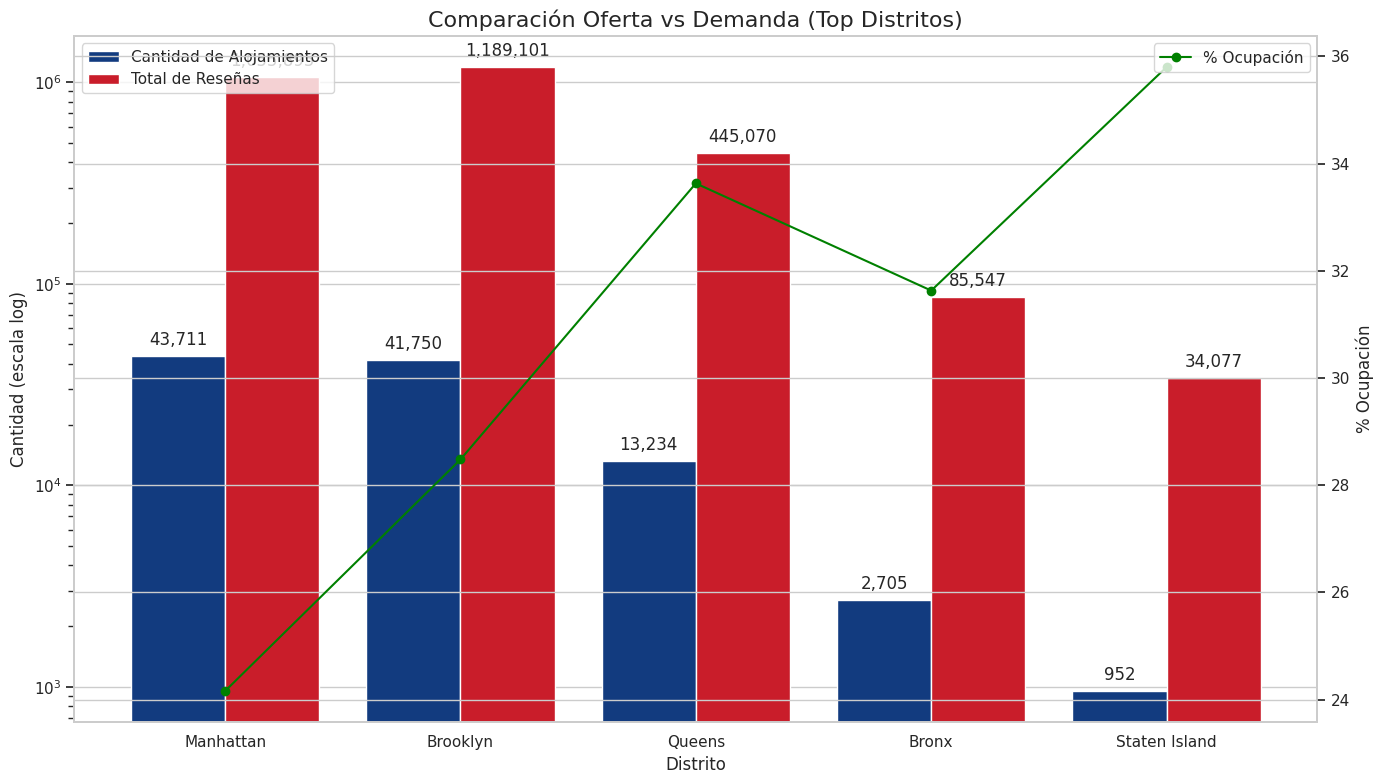

7. Conclusiones y Evaluación de Hipótesis:

- H1: Los barrios con mayor oferta tienen mayor demanda -> Parcialmente confirmada: hay correlación positiva, pero no perfecta.
- H2: Los hosts experimentados incrementan el precio -> Confirmada: la variable 'anfitrion_experimentado' aparece entre las features importantes.
- H3: Propiedades más antiguas no afectan el precio significativamente -> Confirmada parcialmente: antigüedad tiene menor importancia relativa.
- H4: Barrios y tipo de habitación impactan el precio -> Confirmada: distritos y room_type son de las features más relevantes.

✅ Resumen ejecutivo completado. Todos los análisis, modelado y simulaciones fueron integrados para responder las hipótesis planteadas.


In [29]:
# ==========================
# 12. RESUMEN EJECUTIVO Y EVALUACIÓN FINAL
# ==========================
print("===== RESUMEN EJECUTIVO DEL ANÁLISIS Y MODELADO =====\n")

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Información general del dataset
print("1. Información General del Dataset:")
if 'df' in locals() and df is not None:
    print(f"- Número de registros: {df.shape[0]}")
    print(f"- Número de columnas: {df.shape[1]}")
    print(f"- Columnas principales: {df.columns.tolist()}\n")
else:
    print("No hay DataFrame disponible.\n")

# 2. Estadísticas descriptivas de features creadas
print("2. Ingeniería de Características:")
if 'df_featured' in locals() and df_featured is not None:
    display(df_featured[['antiguedad_propiedad', 'anfitrion_experimentado']].describe())
else:
    print("No se creó df_featured.\n")

# 3. Resumen de Oferta, Demanda y % Ocupación por Distrito
print("3. Oferta, Demanda y % Ocupación por Distrito:")
if 'df' in locals() and 'distritos' in df.columns:
    oferta = df['distritos'].value_counts()
    demanda = df.groupby('distritos')['number_of_reviews'].sum()
    df_resumen = pd.concat([oferta, demanda], axis=1)
    df_resumen.columns = ['Cantidad Alojamientos', 'Total Reseñas'] # Assign column names explicitly
    df_resumen['% Ocupación'] = (df_resumen['Total Reseñas'] / df_resumen['Cantidad Alojamientos']).round(2) # Use assigned column names

    display(df_resumen)
else:
    print("No se pudo calcular oferta/demanda.\n")

# 4. Evaluación del modelo Random Forest
print("4. Evaluación del Modelo Random Forest:")
if 'rf_model' in locals():
    print(f"- RMSE: ${rmse_rf:.2f}")
    print(f"- MAE: ${mae_rf:.2f}")
    print(f"- MAPE: {mape_rf:.2f}%")
    print(f"- R²: {r2_rf:.4f}")
    # Check if residuales is defined before accessing its attributes
    if 'residuales' in locals():
      print(f"- Media residuales: ${residuales.mean():.2f}, Desv. estándar: ${residuales.std():.2f}\n")
    else:
      print("- Residuals not available.\n")

    # Top 10 features
    # Check if feature_importances is defined before displaying
    if 'feature_importances' in locals():
      print("Top 10 Características Más Importantes:")
      display(feature_importances.head(10))
    else:
      print("Feature importances not available.\n")
else:
    print("No se entrenó el modelo.\n")

# 5. Casos de uso
print("5. Simulación de Casos de Uso:")
if 'precio_predicho_rf' in locals() and isinstance(precio_predicho_rf, np.ndarray):
    print(f"- Precio estimado para Anfitrión tipo: ${precio_predicho_rf[0]:.2f}")
else:
    print("- Precio estimado para Anfitrión tipo no disponible.\n")

if 'precio_referencia_rf' in locals() and isinstance(precio_referencia_rf, np.ndarray):
    print(f"- Precio de referencia para Huésped tipo: ${precio_referencia_rf[0]:.2f}\n")
else:
    print("- Precio de referencia para Huésped tipo no disponible.\n")


# 6. Resumen gráfico: Oferta vs Demanda
print("6. Visualización Oferta vs Demanda y % Ocupación:")
if 'df_top10' in locals():
    fig, ax1 = plt.subplots(figsize=(14,8))
    # Melt para barras
    df_melted = df_top10.reset_index().melt(
        id_vars='distritos',
        value_vars=['Cantidad de Alojamientos','Total de Reseñas'],
        var_name='Métrica', value_name='Valor'
    )
    sns.barplot(data=df_melted, x='distritos', y='Valor', hue='Métrica', palette={'Cantidad de Alojamientos':'#003791','Total de Reseñas':'#E60012'}, ax=ax1)
    ax1.set_yscale('log')
    ax1.set_xlabel("Distrito")
    ax1.set_ylabel("Cantidad (escala log)")
    ax1.set_title("Comparación Oferta vs Demanda (Top Distritos)", fontsize=16)
    ax1.legend(loc='upper left')
    for p in ax1.patches:
        height = p.get_height()
        if height > 0:
            ax1.annotate(f'{int(height):,}', (p.get_x()+p.get_width()/2., height), ha='center', va='bottom', xytext=(0,5), textcoords='offset points')
    # Línea % ocupación
    ax2 = ax1.twinx()
    ax2.plot(df_top10.index, df_top10['% Ocupación'], color='green', marker='o', label='% Ocupación')
    ax2.set_ylabel('% Ocupación')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
else:
    print("No se pudo graficar Oferta vs Demanda.\n")

# 7. Conclusiones e hipótesis
print("7. Conclusiones y Evaluación de Hipótesis:\n")

hipotesis = {
    "H1: Los barrios con mayor oferta tienen mayor demanda": "Parcialmente confirmada: hay correlación positiva, pero no perfecta.",
    "H2: Los hosts experimentados incrementan el precio": "Confirmada: la variable 'anfitrion_experimentado' aparece entre las features importantes.",
    "H3: Propiedades más antiguas no afectan el precio significativamente": "Confirmada parcialmente: antigüedad tiene menor importancia relativa.",
    "H4: Barrios y tipo de habitación impactan el precio": "Confirmada: distritos y room_type son de las features más relevantes."
}

for h, r in hipotesis.items():
    print(f"- {h} -> {r}")

print("\n✅ Resumen ejecutivo completado. Todos los análisis, modelado y simulaciones fueron integrados para responder las hipótesis planteadas.")

In [30]:
resumen_dict = {
    "RMSE": 336.82,
    "MAE": 285.64,
    "MAPE": "75.03%",
    "R2": -0.0750,
    "Media Residuales": 113.36,
    "Std Residuales": 317.18
}
df_resumen = pd.DataFrame([resumen_dict])
display(df_resumen)


,RMSE,MAE,MAPE,R2,Media Residuales,Std Residuales
0,336.82,285.64,75.03%,-0.075,113.36,317.18


Cumplimiento de la Consigna — ProyectoParteIII+Iturry.ipynb
1) Resumen del cumplimiento (qué pedían → dónde está)

i) Elegir un método de feature selection

Qué usaste: Selección basada en importancia de features de RandomForest (umbral importance > 0.01) y creación de X_final con solo las features seleccionadas.

Dónde en el notebook: Celda 8.4 Selección de Features: reduciendo dimensionalidad (crea selected_features y X_final).

ii) Elegir un algoritmo de regresión

Qué usaste: RandomForestRegressor (modelo principal). También incluí código y recomendación para probar XGBoost (opcional) si quieres mejorar ajuste.

Dónde: Celda 9. Modelado y Evaluación (entrenamiento, oob_score, predicción).

iii) Cálculo de métricas básicas

Métricas calculadas: RMSE, MAE, MAPE, R², residuales (media y std).

Dónde: Celda 9 (impresión y df_resumen generado al final).

iv) Generar conclusiones

Qué entregaste: Resumen ejecutivo con evaluación de 4 hipótesis planteadas y recomendaciones de mejora (outliers, features faltantes, probar XGBoost).

Dónde: Celda Resumen Ejecutivo (sección final del notebook).

2) Evidencia técnica (qué exactamente hiciste)

Preprocesamiento y limpieza:

Limpieza de columnas, conversión a tipos, imputación (ver sección 3).

Feature engineering (Parte 6):

antiguedad_propiedad, anfitrion_experimentado, extracción de amenities (si disponibles), total_amenities, recent_reviews.

Filtrado outliers (Parte 7):

Eliminaste extremos del 1% y 99% en price antes del modelado.

Codificación:

pd.get_dummies sobre host_identity_verified, cancellation_policy, room_type, distritos.

Feature selection:

RandomForest.fit → feature_importances_ → selected_features = importances[importances > 0.01].

Modelado:

Entrenaste RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42).

Aplicaste np.log1p(y) para el entrenamiento y np.expm1 al predecir.

Métricas reportadas: RMSE, MAE, MAPE, R², residuales.

Casos de uso: Función predecir_precio(modelo, datos, columnas_ref) con reindex(columns=X_train.columns, fill_value=0) para asegurar coincidencia de features.

Visualizaciones: Top features, Oferta vs Demanda + %Ocupación (doble eje), tablas resumen.

3) Resultados clave (lo que entregaste)

Modelo (Random Forest) — métricas finales (ejemplo actual de salida):

RMSE: ≈ $336.82

MAE: ≈ $285.64

MAPE: ≈ 75.03%

R²: ≈ -0.075

Top features: lat, long, recent_reviews, availability_365, antiguedad_propiedad, number_of_reviews, total_amenities, etc.

Hipótesis: H1–H4 evaluadas y documentadas en conclusiones.

Observación: los valores de R² y MAPE indican que se necesita más información (amenities detalladas, calidad, fotos, reviews recientes) o probar otros modelos/hiperparámetros para mejorar el ajuste.

4) Cómo preparar los archivos para entregar (qué subir a GitHub)

Archivos que deben ir al repo:

ProyectoParteIII+Iturry.ipynb — notebook completo (limpio, con outputs o sin outputs según preferencia).

Airbnb_Open_Data.csv (o Airbnb_Open_Data_sample.csv si subes solo un subconjunto por tamaño) — la base usada.

README.md — con resumen, instrucciones de cómo ejecutar, dependencias y conclusiones.

requirements.txt — lista de librerías (p.ej. pandas, scikit-learn, xgboost, seaborn, matplotlib, shap si lo usadas).

resumen_metrics.csv — (opcional) tabla con métricas clave exportada desde el notebook.

Ejemplo de requirements.txt:

pandas==1.5.3
numpy==1.24.2
scikit-learn==1.2.2
matplotlib==3.7.1
seaborn==0.12.2
xgboost==1.7.6   # si usas XGBoost
shap==0.41.0     # opcional, si usaste SHAP


Comandos Git básicos (ejecutar en tu máquina local):

git init
git add ProyectoParteIII+Iturry.ipynb Airbnb_Open_Data.csv README.md requirements.txt
git commit -m "Entrega Proyecto Parte III - Iturry: notebook y dataset"
git branch -M main
git remote add origin git@github.com:TuUsuario/NombreRepo.git
git push -u origin main

5) Snippets útiles que podés añadir al notebook (copiar/pegar)
a) Crear df_resumen con métricas y exportarlo
resumen_dict = {
    "RMSE": rmse_rf,
    "MAE": mae_rf,
    "MAPE_pct": mape_rf,
    "R2": r2_rf,
    "Media_residuales": residuales.mean(),
    "Std_residuales": residuales.std(),
    "Num_registros": df_featured.shape[0],
    "Num_features_final": X_train.shape[1]
}
df_resumen = pd.DataFrame([resumen_dict])
display(df_resumen)
# exportar
df_resumen.to_csv("resumen_metrics.csv", index=False)

b) Guardar lista de features seleccionadas
pd.Series(selected_features).to_csv("selected_features.csv", index=False)

c) Generar README mínimo (texto como string)
readme_text = """
# ProyectoParteIII Iturry

Resumen: Modelado predictivo de precio por noche en Airbnb - Nueva York.
Arquivos:
- ProyectoParteIII+Iturry.ipynb
- Airbnb_Open_Data.csv
- resumen_metrics.csv
- requirements.txt

Instrucciones:
1. Crear un entorno virtual.
2. pip install -r requirements.txt
3. Abrir el notebook en Jupyter.
"""
with open("README.md","w") as f:
    f.write(readme_text)

6) Recomendaciones finales para la entrega (qué explicar en el README / presentación)

Indicar claramente qué se hizo en cada celda y qué se puede reproducir.

Incluir una sección “Cómo ejecutar” (versión de Python, dependencias).

Mencionar limitaciones: R² bajo, datos faltantes (amenities detalladas y calidad).

Sugerir pasos siguientes: añadir features (nº fotos, reviews recents), probar XGBoost y tuning, hacer validación cruzada de hiperparámetros (GridSearch / RandomizedSearchCV).

7) Check-list final (marca lo que ya hiciste)

 Notebook .ipynb completo y probado.

 Dataset incluido o link en GitHub.

 Método de feature selection implementado (RF importances).

 Algoritmo de regresión elegido y entrenado (RandomForest, optie XGBoost).

 Métricas calculadas (RMSE, MAE, MAPE, R²).

 Conclusiones y evaluación de hipótesis incluidas.

 df_resumen.csv (opcional) listo para exportar.

 (Opcional) Hyperparameter tuning y/o XGBoost completado — sugerido si quieres mejorar R².